In [ ]:
# Step 1: Install NLTK if not already installed
# pip install nltk

# Step 2: Import libraries
import nltk
from nltk.corpus import wordnet as wn
nltk.download('punkt')
# Step 3: Download WordNet data (if not already downloaded)
nltk.download('wordnet')

# Step 4: Get synsets for the word "car"
synsets = wn.synsets('car')
print("All synsets for 'car':")
for syn in synsets:
    print(syn, "-", syn.definition())

# Step 5: Explore synonyms (lemmas) for the first synset
car_synonyms = synsets[0].lemma_names()
print("\nSynonyms for 'car':", car_synonyms)

# Step 6: Explore hypernyms (more general terms)
car_hypernyms = synsets[0].hypernyms()
print("\nHypernyms (general term) of 'car':")
for hyper in car_hypernyms:
    print(hyper, "-", hyper.definition())

# Step 7: Explore hyponyms (more specific terms)
car_hyponyms = synsets[0].hyponyms()
print("\nHyponyms (specific types) of 'car':")
for hypo in car_hyponyms:
    print(hypo, "-", hypo.definition())


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


All synsets for 'car':
Synset('car.n.01') - a motor vehicle with four wheels; usually propelled by an internal combustion engine
Synset('car.n.02') - a wheeled vehicle adapted to the rails of railroad
Synset('car.n.03') - the compartment that is suspended from an airship and that carries personnel and the cargo and the power plant
Synset('car.n.04') - where passengers ride up and down
Synset('cable_car.n.01') - a conveyance for passengers or freight on a cable railway

Synonyms for 'car': ['car', 'auto', 'automobile', 'machine', 'motorcar']

Hypernyms (general term) of 'car':
Synset('motor_vehicle.n.01') - a self-propelled wheeled vehicle that does not run on rails

Hyponyms (specific types) of 'car':
Synset('cruiser.n.01') - a car in which policemen cruise the streets; equipped with radiotelephonic communications to headquarters
Synset('hatchback.n.01') - a car having a hatchback door
Synset('sedan.n.01') - a car that is closed and that has front and rear seats and two or four doors
S

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [ ]:
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize, sent_tokenize
import string
import textwrap
import re
import time

# Download necessary NLTK data (run once)
try:
    nltk.data.find('tokenizers/punkt')
except nltk.downloader.DownloadError:
    nltk.download('punkt')
try:
    nltk.data.find('corpora/stopwords')
except nltk.downloader.DownloadError:
    nltk.download('stopwords')

# --- Configuration ---
TOP_K_DOCUMENTS = 3  # Number of top documents to retrieve
TOP_K_SENTENCES = 2  # Number of top sentences to extract from retrieved documents

# --- Preprocessing Utilities ---
STOP_WORDS = set(stopwords.words('english'))
PUNCTUATION = set(string.punctuation)

def preprocess_text(text: str) -> str:
    """
    Converts text to lowercase, removes punctuation, and removes stopwords.
    """
    text = text.lower()
    text = ''.join(char for char in text if char not in PUNCTUATION)
    tokens = word_tokenize(text)
    filtered_tokens = [word for word in tokens if word not in STOP_WORDS]
    return ' '.join(filtered_tokens)

def tokenize_sentences(text: str) -> list[str]:
    """
    Splits a document into individual sentences.
    """
    return sent_tokenize(text)

# --- 1. Knowledge Base Management (Classical) ---
class ClassicalKnowledgeBase:
    """
    Manages the collection of documents, their TF-IDF representations,
    and provides retrieval functionality using cosine similarity.
    """
    def __init__(self, documents: list[str]):
        self.raw_documents = documents
        self.preprocessed_documents = [preprocess_text(doc) for doc in documents]
        self.tfidf_vectorizer = TfidfVectorizer()
        self.document_tfidf_matrix = None
        self._build_index()

    def _build_index(self):
        """
        Fits the TF-IDF vectorizer on the preprocessed documents
        and transforms them into a TF-IDF matrix.
        """
        print(f"Building TF-IDF index for {len(self.raw_documents)} documents...")
        start_time = time.time()
        self.document_tfidf_matrix = self.tfidf_vectorizer.fit_transform(self.preprocessed_documents)
        end_time = time.time()
        print(f"TF-IDF index built in {end_time - start_time:.2f} seconds.")
        print(f"TF-IDF matrix shape: {self.document_tfidf_matrix.shape}")

    def retrieve_documents(self, query: str, top_k: int = TOP_K_DOCUMENTS) -> list[tuple[str, float]]:
        """
        Retrieves the top_k most relevant documents based on the query
        using TF-IDF and cosine similarity.

        Args:
            query (str): The user's question.
            top_k (int): The number of top documents to retrieve.

        Returns:
            list[tuple[str, float]]: A list of (document_text, similarity_score) tuples.
        """
        preprocessed_query = preprocess_text(query)
        query_tfidf_vector = self.tfidf_vectorizer.transform([preprocessed_query])

        # Calculate cosine similarity between query and all documents
        similarities = cosine_similarity(query_tfidf_vector, self.document_tfidf_matrix).flatten()

        # Get indices of top_k most similar documents
        top_doc_indices = similarities.argsort()[-top_k:][::-1] # Sort descending

        retrieved_docs_with_scores = []
        for idx in top_doc_indices:
            retrieved_docs_with_scores.append((self.raw_documents[idx], similarities[idx]))

        print(f"Retrieved {len(retrieved_docs_with_scores)} documents.")
        # print(f"Top similarities: {[score for _, score in retrieved_docs_with_scores]}")
        return retrieved_docs_with_scores

# --- 2. Question Answering System (Classical) ---
class ClassicalQuestionAnsweringSystem:
    """
    Orchestrates the retrieval of relevant documents and the extraction of an answer
    using classical NLP techniques.
    """
    def __init__(self, knowledge_base: ClassicalKnowledgeBase):
        self.knowledge_base = knowledge_base

    def _extract_answer_sentence(self, question: str, context_documents: list[str], top_k_sentences: int = TOP_K_SENTENCES) -> str:
        """
        Extracts the most relevant sentences from the context documents
        based on keyword overlap with the question.

        Args:
            question (str): The user's question.
            context_documents (list[str]): The retrieved documents.
            top_k_sentences (int): Number of top sentences to return.

        Returns:
            str: The extracted answer sentence(s).
        """
        question_tokens = set(word_tokenize(preprocess_text(question)))
        all_sentences = []
        for doc in context_documents:
            all_sentences.extend(tokenize_sentences(doc))

        if not all_sentences:
            return "No relevant sentences found in the context."

        sentence_scores = []
        for sentence in all_sentences:
            preprocessed_sentence = preprocess_text(sentence)
            sentence_tokens = set(word_tokenize(preprocessed_sentence))

            # Calculate keyword overlap (Jaccard similarity or simple count)
            common_tokens = question_tokens.intersection(sentence_tokens)
            score = len(common_tokens) # Simple count of shared keywords

            # Optionally, you could use TF-IDF for sentences too, but for simplicity,
            # keyword overlap is a common classical approach for sentence scoring.

            sentence_scores.append((sentence, score))

        # Sort sentences by score in descending order
        sentence_scores.sort(key=lambda x: x[1], reverse=True)

        # Combine top_k_sentences into a single answer
        extracted_answer = " ".join([s[0] for s in sentence_scores[:top_k_sentences] if s[1] > 0])

        if not extracted_answer:
            return "I couldn't find a direct answer in the retrieved context."

        return extracted_answer

    def answer_question(self, question: str) -> str:
        """
        Main method to answer a question using classical NLP.
        1. Retrieves relevant documents.
        2. Extracts the most relevant sentence(s) from those documents.
        """
        print(f"\n--- Answering Question: '{question}' ---")

        # 1. Retrieve relevant documents
        retrieved_docs_with_scores = self.knowledge_base.retrieve_documents(question, top_k=TOP_K_DOCUMENTS)
        retrieved_docs = [doc for doc, _ in retrieved_docs_with_scores]

        if not retrieved_docs:
            return "I could not find any relevant information in the knowledge base."

        print(f"\n--- Retrieved Context ({len(retrieved_docs)} documents) ---")
        for i, (doc, score) in enumerate(retrieved_docs_with_scores):
            print(f"Document {i+1} (Similarity: {score:.4f}):")
            print(textwrap.fill(doc, width=100))
            print("-" * 20)
        print("--------------------------------------------------")

        # 2. Extract answer sentence(s) from the retrieved context
        answer = self._extract_answer_sentence(question, retrieved_docs, top_k_sentences=TOP_K_SENTENCES)

        return answer

# --- 3. Main Execution Block ---
if __name__ == "__main__":
    # --- Define your Knowledge Base Documents ---
    documents = [
        "The Amazon rainforest is the largest rainforest in the world, covering much of northwestern South America. It is home to an incredible diversity of wildlife, including jaguars, tapirs, and anacondas.",
        "The Amazon River, flowing through the Amazon rainforest, is the largest river by discharge volume of water in the world. It originates in the Andes Mountains of Peru and empties into the Atlantic Ocean.",
        "Deforestation in the Amazon is a major environmental concern, driven primarily by cattle ranching and agriculture. It leads to habitat loss, climate change, and loss of biodiversity.",
        "Brazil contains the largest portion of the Amazon rainforest, approximately 60%. Other countries include Peru, Colombia, Ecuador, Bolivia, Venezuela, Guyana, Suriname, and French Guiana.",
        "The capital of France is Paris, a major European city and a global center for art, fashion, gastronomy, and culture. Its 19th-century cityscape is crisscrossed by wide boulevards and the River Seine.",
        "Eiffel Tower, a wrought-iron lattice tower on the Champ de Mars in Paris, France, is one of the most recognizable structures in the world. It was constructed from 1887 to 1889 as the entrance to the 1889 World's Fair.",
        "The Great Barrier Reef is the world's largest coral reef system, located off the coast of Queensland, Australia. It is composed of over 3,000 individual reefs and 900 islands stretching for over 2,300 kilometers.",
        "Coral bleaching is a significant threat to coral reefs worldwide, including the Great Barrier Reef. It occurs when corals expel algae living in their tissues, causing them to turn white and often die.",
        "Artificial intelligence (AI) is a broad field of computer science that gives computers the ability to perform human-like cognitive functions such as learning, problem-solving, and decision-making.",
        "Machine learning is a subset of AI that focuses on the development of algorithms that allow computers to learn from data without being explicitly programmed. Deep learning is a further subset of machine learning.",
        "Natural Language Processing (NLP) is a field of AI that enables computers to understand, interpret, and generate human language. It's used in applications like translation, sentiment analysis, and chatbots."
    ]

    # --- Initialize Knowledge Base ---
    kb = ClassicalKnowledgeBase(documents)

    # --- Initialize Question Answering System ---
    qa_system = ClassicalQuestionAnsweringSystem(kb)

    # --- Ask Questions ---
    questions = [
        "What is the Amazon rainforest?",
        "Where does the Amazon River originate?",
        "What is the main cause of deforestation in the Amazon?",
        "Which country holds the largest part of the Amazon rainforest?",
        "What is the capital of France?",
        "What is the Eiffel Tower?",
        "What is the Great Barrier Reef?",
        "What is coral bleaching?",
        "What is Natural Language Processing?",
        "Who invented the internet?", # This question is not directly answerable from the KB
        "Tell me about machine learning."
    ]

    for i, question in enumerate(questions):
        print(f"\n{'='*80}\nQUESTION {i+1}: {question}\n{'='*80}")
        answer = qa_system.answer_question(question)
        print(f"\nFINAL ANSWER: {textwrap.fill(answer, width=100)}\n")
        print(f"{'-'*80}\n")

    # --- Interactive Mode (Optional) ---
    print("\n--- Entering Interactive QA Mode ---")
    print("Type 'exit' to quit.")
    while True:
        user_question = input("\nYour question: ")
        if user_question.lower() == 'exit':
            break
        if not user_question.strip():
            print("Please enter a question.")
            continue

        answer = qa_system.answer_question(user_question)
        print(f"\nFINAL ANSWER: {textwrap.fill(answer, width=100)}\n")

AttributeError: module 'nltk.downloader' has no attribute 'DownloadError'

In [ ]:
import re
import warnings
import os
import nltk
from nltk.tokenize import sent_tokenize, word_tokenize
from collections import Counter
from math import sqrt

# Optional: For better context relevance, we can still use sentence-transformers.
# If you want to remove ALL transformers, including sentence-transformers,
# then the semantic similarity check will need to be replaced with a simpler
# keyword overlap or Jaccard similarity.
# For now, I'll keep sentence-transformers for semantic similarity as it's
# not directly performing QA, but providing embeddings.
try:
    from sentence_transformers import SentenceTransformer, util
    SENTENCE_TRANSFORMERS_AVAILABLE = True
except ImportError:
    print("Warning: sentence-transformers not found. Semantic similarity checks will be disabled.")
    SENTENCE_TRANSFORMERS_AVAILABLE = False
nltk.download('stopwords')
# Download NLTK data if not already present
try:
    nltk.data.find('tokenizers/punkt')
except nltk.downloader.DownloadError:
    nltk.download('punkt')
try:
    nltk.data.find('corpora/stopwords')
except nltk.downloader.DownloadError:
    nltk.download('stopwords')

from nltk.corpus import stopwords
STOPWORDS = set(stopwords.words('english'))

# Suppress specific warnings for cleaner output
warnings.filterwarnings("ignore", category=UserWarning)

class EthicalQASystemNoTransformers:
    """
    A Question Answering (QA) system with integrated ethical guidelines,
    implemented WITHOUT the Hugging Face Transformers library for QA.
    Uses a simpler keyword-based approach for QA.
    """

    def __init__(self,
                 sentence_transformer_model="all-MiniLM-L6-v2", # Used only for semantic relevance if available
                 threshold_confidence=0.5, # Lowered for keyword-based QA
                 threshold_similarity=0.3): # Lowered for keyword-based QA
        """
        Initializes the EthicalQASystemNoTransformers.

        Args:
            sentence_transformer_model (str): The name of the sentence transformer model
                                              for semantic similarity checks (if available).
            threshold_confidence (float): Minimum confidence score for an answer to be
                                          considered reliable.
            threshold_similarity (float): Minimum semantic similarity score for a question
                                          to be considered relevant to the context.
        """
        print("Initializing QA system without Hugging Face Transformers for core QA.")

        self.st_device_name = 'cuda' if torch.cuda.is_available() else 'cpu' if SENTENCE_TRANSFORMERS_AVAILABLE else None
        if SENTENCE_TRANSFORMERS_AVAILABLE:
            print(f"Initializing Sentence Transformer model: {sentence_transformer_model}...")
            self.sentence_model = SentenceTransformer(sentence_transformer_model, device=self.st_device_name)
            print(f"Sentence Transformer model loaded on device: {self.st_device_name}.")
        else:
            self.sentence_model = None
            print("Sentence Transformer not available. Semantic similarity checks will be skipped.")

        self.threshold_confidence = threshold_confidence
        self.threshold_similarity = threshold_similarity

        # --- Ethical Guidelines Configuration ---
        self.bias_keywords = [
            "male", "female", "man", "woman", "boy", "girl", "he", "she", "him", "her",
            "black", "white", "asian", "hispanic", "immigrant", "refugee",
            "gay", "lesbian", "straight", "christian", "muslim", "jewish", "hindu",
            "rich", "poor", "disabled", "abled", "elderly", "young",
            "terrorist", "criminal", "illegal", "victim", "perpetrator",
            "doctor", "nurse", "engineer", "secretary", "CEO", "janitor",
            "boss", "subordinate", "leader", "follower"
        ]
        self.harmful_patterns = [
            re.compile(r'\b(kill|murder|rape|assault|hate|nazi|supremacy|terrorist|bomb|explod|weapon|firearm|poison)\b', re.IGNORECASE),
            re.compile(r'\b(fag|nigg?er|chink|kike|spic|tranny|retard|incel|pedophile)\b', re.IGNORECASE), # Offensive slurs
            re.compile(r'\b(suicide|self-harm|cut myself|end my life)\b', re.IGNORECASE), # Self-harm related
            re.compile(r'\b(child porn|sexual abuse|exploitation)\b', re.IGNORECASE) # Illegal content
        ]
        self.disclaimer = (
            "Disclaimer: This is an AI-generated answer. While efforts are made to ensure accuracy "
            "and fairness, this system uses a simple keyword-based approach and can be highly inaccurate. "
            "Always verify critical information with reliable human sources."
        )

    def _check_for_harmful_content(self, text):
        """
        Checks if the given text contains harmful or offensive content.
        """
        detected_patterns = []
        for pattern in self.harmful_patterns:
            if pattern.search(text):
                detected_patterns.append(pattern.pattern)
        return bool(detected_patterns), detected_patterns

    def _check_for_bias_keywords(self, text):
        """
        Identifies potential bias-related keywords in the text.
        """
        detected_keywords = sorted(list(set([kw for kw in self.bias_keywords if kw in text.lower()])))
        return detected_keywords

    def _calculate_semantic_similarity(self, text1, text2):
        """
        Calculates the semantic similarity between two texts using Sentence Transformers.
        Returns 0.0 if sentence-transformers is not available.
        """
        if not SENTENCE_TRANSFORMERS_AVAILABLE or not self.sentence_model or not text1 or not text2:
            return 0.0 # Cannot calculate semantic similarity
        try:
            embeddings1 = self.sentence_model.encode(text1, convert_to_tensor=True, device=self.st_device_name)
            embeddings2 = self.sentence_model.encode(text2, convert_to_tensor=True, device=self.st_device_name)
            cosine_scores = util.cos_sim(embeddings1, embeddings2)
            return cosine_scores.item()
        except Exception as e:
            print(f"Error calculating semantic similarity: {e}. Returning 0.0.")
            return 0.0

    def _simple_qa_logic(self, question, context):
        """
        A very simple keyword-based QA logic.
        Finds the sentence in the context that shares the most non-stopwords with the question.
        """
        if not context or not question:
            return "", 0.0, -1, -1

        question_words = set(word.lower() for word in word_tokenize(question) if word.isalpha() and word.lower() not in STOPWORDS)

        if not question_words: # If question is just stopwords or punctuation
            return "", 0.0, -1, -1

        sentences = sent_tokenize(context)
        best_sentence = ""
        max_matches = 0
        best_score = 0.0
        start_idx = -1
        end_idx = -1

        for i, sentence in enumerate(sentences):
            sentence_words = set(word.lower() for word in word_tokenize(sentence) if word.isalpha() and word.lower() not in STOPWORDS)

            common_words = question_words.intersection(sentence_words)
            num_matches = len(common_words)

            # Simple scoring: number of common words, normalized by question length
            # Add a small bonus for longer sentences that still match well
            score = num_matches / len(question_words) if len(question_words) > 0 else 0.0
            if len(sentence_words) > 0:
                score += (num_matches / len(sentence_words)) * 0.1 # Small bonus for context coverage

            if score > best_score:
                best_score = score
                best_sentence = sentence
                # Find approximate start/end for transparency (not exact span)
                start_idx = context.find(sentence)
                end_idx = start_idx + len(sentence)

        # Adjust confidence based on score (e.g., scale to 0-1)
        # This is heuristic; a real system would need training data for confidence.
        confidence = min(1.0, best_score * 0.8 + (0.2 if best_sentence else 0)) # Heuristic scaling

        return best_sentence, confidence, start_idx, end_idx


    def answer_question(self, question, context):
        """
        Answers a question based on the provided context, incorporating ethical checks.
        Uses a simple keyword-based QA logic.
        """
        results = {
            "answer": None,
            "confidence": 0.0,
            "start": -1,
            "end": -1,
            "ethical_flags": {
                "harmful_question": False,
                "harmful_answer": False,
                "low_confidence": False,
                "potential_bias_in_question": [],
                "potential_bias_in_answer": [],
                "context_relevance_warning": False,
                "requires_verification": False,
                "no_answer_found": False
            },
            "ethical_messages": [],
            "disclaimer": self.disclaimer
        }

        # --- 1. Pre-check: Harmful Question Detection ---
        is_harmful_q, harmful_q_patterns = self._check_for_harmful_content(question)
        if is_harmful_q:
            results["ethical_flags"]["harmful_question"] = True
            results["ethical_messages"].append(
                f"Warning: The question contains potentially harmful or offensive content: {', '.join(harmful_q_patterns)}. "
                "I cannot process questions that contain harmful or offensive language."
            )
            results["answer"] = "I cannot process questions that contain harmful or offensive language."
            return results

        # --- 2. Pre-check: Question Bias Keywords ---
        bias_q_keywords = self._check_for_bias_keywords(question)
        if bias_q_keywords:
            results["ethical_flags"]["potential_bias_in_question"] = bias_q_keywords
            results["ethical_messages"].append(
                f"Note: The question contains keywords that could indicate bias: {', '.join(bias_q_keywords)}. "
                "Please ensure your question is neutral and respectful."
            )

        # --- 3. Pre-check: Context Relevance ---
        if SENTENCE_TRANSFORMERS_AVAILABLE:
            context_similarity = self._calculate_semantic_similarity(question, context)
            if context_similarity < self.threshold_similarity:
                results["ethical_flags"]["context_relevance_warning"] = True
                results["ethical_messages"].append(
                    f"Warning: The question's semantic similarity to the context is low ({context_similarity:.2f}). "
                    "The answer might not be directly relevant or accurate based on the provided context."
                )
        else:
            results["ethical_messages"].append("Note: Semantic relevance check skipped (sentence-transformers not available).")


        # --- 4. Core QA Logic (Simple Keyword-based) ---
        answer, confidence, start_idx, end_idx = self._simple_qa_logic(question, context)
        results["answer"] = answer
        results["confidence"] = confidence
        results["start"] = start_idx
        results["end"] = end_idx

        if not results["answer"]:
            results["ethical_flags"]["no_answer_found"] = True
            results["ethical_messages"].append("Could not find a relevant answer in the provided context using keyword matching.")
            results["answer"] = "I apologize, but I could not find a relevant answer to your question in the provided context."
            results["confidence"] = 0.0 # Ensure confidence is 0 if no answer found
            # No need to proceed with post-checks if no answer was found
            return results

        # --- 5. Post-check: Harmful Answer Detection ---
        is_harmful_a, harmful_a_patterns = self._check_for_harmful_content(results["answer"])
        if is_harmful_a:
            results["ethical_flags"]["harmful_answer"] = True
            results["ethical_messages"].append(
                f"Critical: The generated answer contains potentially harmful or offensive content: {', '.join(harmful_a_patterns)}. "
                "This answer should not be trusted or disseminated."
            )
            results["answer"] = "I cannot provide an answer that contains harmful or offensive language."
            results["confidence"] = 0.0 # Invalidate confidence
            return results # Exit early if answer is harmful

        # --- 6. Post-check: Answer Bias Keywords ---
        bias_a_keywords = self._check_for_bias_keywords(results["answer"])
        if bias_a_keywords:
            results["ethical_flags"]["potential_bias_in_answer"] = bias_a_keywords
            results["ethical_messages"].append(
                f"Warning: The generated answer contains keywords that could indicate bias: {', '.join(bias_a_keywords)}. "
                "Please interpret this answer with caution and consider potential biases."
            )

        # --- 7. Post-check: Confidence Threshold ---
        if results["confidence"] < self.threshold_confidence:
            results["ethical_flags"]["low_confidence"] = True
            results["ethical_flags"]["requires_verification"] = True
            results["ethical_messages"].append(
                f"Warning: The system's confidence in this answer is low ({results['confidence']:.2f}). "
                "This answer requires independent verification."
            )
        else:
            results["ethical_flags"]["requires_verification"] = True
            results["ethical_messages"].append(
                f"Note: For critical information, always verify with reliable human sources, "
                "even with high AI confidence."
            )

        # --- 8. Transparency: Source Highlighting (Conceptual) ---
        if results["start"] != -1 and results["end"] != -1:
            results["ethical_messages"].append(
                f"Transparency: The answer was extracted from the context between characters {results['start']} and {results['end']}."
            )

        return results

    def display_results(self, question, context, qa_results):
        """
        Prints the QA results in a user-friendly and ethically transparent format.
        """
        print("\n" + "="*80)
        print(f"Question: {question}")
        print(f"Context: {context[:200]}... (truncated for display)")
        print("-" * 80)

        print(f"Answer: {qa_results['answer']}")
        print(f"Confidence: {qa_results['confidence']:.2f}")

        print("\n--- Ethical Considerations ---")
        if qa_results["ethical_messages"]:
            for msg in qa_results["ethical_messages"]:
                print(f"- {msg}")
        else:
            print("- No specific ethical flags raised for this interaction.")

        print("\n--- Ethical Flags ---")
        for flag, value in qa_results["ethical_flags"].items():
            if isinstance(value, list) and value:
                print(f"- {flag.replace('_', ' ').title()}: {', '.join(value)}")
            elif value is True:
                print(f"- {flag.replace('_', ' ').title()}: Yes")
            elif value is False:
                print(f"- {flag.replace('_', ' ').title()}: No")

        print("\n" + qa_results["disclaimer"])
        print("="*80)

        # --- User Feedback Prompt ---
        print("\nWas this answer helpful, accurate, or problematic? Your feedback helps improve the system.")
        print("Please report any issues (e.g., bias, inaccuracy, harmful content) to our moderation team.")
        print("="*80 + "\n")


# --- Example Usage ---
if __name__ == "__main__":
    # Initialize the QA system (without transformers for core QA)
    # If sentence-transformers is not installed, semantic relevance will be skipped.
    qa_system = EthicalQASystemNoTransformers()

    # --- Run predefined scenarios ---
    print("\n--- Running Predefined Scenarios ---")

    # Scenario 1: Standard Question
    print("\n--- Scenario 1: Standard Question ---")
    context1 = (
        "The Amazon rainforest is the largest tropical rainforest in the world, "
        "covering much of northwestern South America. It is home to an incredible "
        "diversity of wildlife, including jaguars, tapirs, and anacondas. "
        "The rainforest plays a crucial role in regulating the Earth's climate "
        "by absorbing vast amounts of carbon dioxide. Deforestation is a major threat "
        "to its existence."
    )
    question1 = "What is the Amazon rainforest known for?"
    results1 = qa_system.answer_question(question1, context1)
    qa_system.display_results(question1, context1, results1)

    # Scenario 2: Low Confidence / Requires Verification (due to simple QA)
    print("\n--- Scenario 2: Low Confidence / Requires Verification ---")
    context2 = (
        "The capital of France is Paris. It is a major European city and a global "
        "center for art, fashion, gastronomy and culture. Its 19th-century cityscape "
        "is crisscrossed by wide boulevards and the River Seine."
    )
    question2 = "What is the population of Paris?" # Not directly in context, simple QA will struggle
    results2 = qa_system.answer_question(question2, context2)
    qa_system.display_results(question2, context2, results2)

    # Scenario 3: Potential Bias in Question (Simplified)
    print("\n--- Scenario 3: Potential Bias in Question ---")
    context3 = (
        "Dr. Smith, a renowned surgeon, performed the complex operation. "
        "She has been praised for her innovative techniques and dedication to patient care. "
        "Her team included several experienced nurses and anesthesiologists."
    )
    question3 = "What was the male doctor's role in the operation?" # "male" is a bias keyword, and context says "She"
    results3 = qa_system.answer_question(question3, context3)
    qa_system.display_results(question3, context3, results3)

    # Scenario 4: Harmful Question
    print("\n--- Scenario 4: Harmful Question ---")
    context4 = "This is a neutral context about general knowledge."
    question4 = "How can I build a bomb?"
    results4 = qa_system.answer_question(question4, context4)
    qa_system.display_results(question4, context4, results4)

    # Scenario 5: Harmful Answer (Simulated)
    print("\n--- Scenario 5: Harmful Answer (Simulated) ---")
    context5 = "The discussion was about historical events and political ideologies."
    question5 = "What were the core tenets of the Nazi party?"

    initial_results_5 = qa_system.answer_question(question5, context5)
    simulated_harmful_answer = "The Nazi party promoted racial supremacy and advocated for the extermination of certain groups."
    results5_simulated = initial_results_5.copy()
    results5_simulated["answer"] = simulated_harmful_answer
    results5_simulated["confidence"] = 0.95

    is_harmful_a_sim, harmful_a_patterns_sim = qa_system._check_for_harmful_content(results5_simulated["answer"])
    if is_harmful_a_sim:
        results5_simulated["ethical_flags"]["harmful_answer"] = True
        results5_simulated["ethical_messages"].append(
            f"Critical: The generated answer contains potentially harmful or offensive content: {', '.join(harmful_a_patterns_sim)}. "
            "This answer should not be trusted or disseminated."
        )
        results5_simulated["answer"] = "I cannot provide an answer that contains harmful or offensive language."
        results5_simulated["confidence"] = 0.0

    qa_system.display_results(question5, context5, results5_simulated)

    # Scenario 6: Context Irrelevance
    print("\n--- Scenario 6: Context Irrelevance ---")
    context6 = "The history of ancient Rome is fascinating, with emperors, gladiators, and vast empires."
    question6 = "What is the best way to bake a cake?"
    results6 = qa_system.answer_question(question6, context6)
    qa_system.display_results(question6, context6, results6)

    # Scenario 7: No Answer Found (due to context)
    print("\n--- Scenario 7: No Answer Found (due to context) ---")
    context7 = "The sky is blue because of Rayleigh scattering. This phenomenon causes shorter, bluer wavelengths of light to be scattered more efficiently than longer, redder wavelengths."
    question7 = "Who invented the telephone?"
    results7 = qa_system.answer_question(question7, context7)
    qa_system.display_results(question7, context7, results7)

    # Scenario 8: Empty Context
    print("\n--- Scenario 8: Empty Context ---")
    context8 = ""
    question8 = "What is the capital of France?"
    results8 = qa_system.answer_question(question8, context8)
    qa_system.display_results(question8, context8, results8)

    # Scenario 9: Empty Question
    print("\n--- Scenario 9: Empty Question ---")
    context9 = "The capital of France is Paris."
    question9 = ""
    results9 = qa_system.answer_question(question9, context9)
    qa_system.display_results(question9, context9, results9)

    print("\n--- End of Predefined Scenarios ---")
    print("\n--- Starting Interactive QA Session ---")
    print("Enter your question and context. Type 'exit' for question to quit.")
    print("For context, you can paste a paragraph or type 'default' for a generic one.")

    default_interactive_context = (
        "Natural Language Processing (NLP) is a field of artificial intelligence "
        "that focuses on enabling computers to understand, interpret, and generate "
        "human language. It combines computational linguistics—rule-based modeling "
        "of human language—with statistical, machine learning, and deep learning models. "
        "NLP applications include machine translation, spam detection, sentiment analysis, "
        "and chatbots. The goal is to bridge the gap between human communication and computer understanding."
    )

    while True:
        user_question = input("\nYour question (type 'exit' to quit): ")
        if user_question.lower() == 'exit':
            print("Exiting interactive session. Goodbye!")
            break
        if not user_question.strip():
            print("Question cannot be empty. Please try again.")
            continue

        user_context_choice = input("Enter context (paste text or type 'default' for a generic NLP context): ")
        if user_context_choice.lower() == 'default':
            user_context = default_interactive_context
            print(f"Using default context: {user_context[:100]}...")
        elif not user_context_choice.strip():
            print("Context cannot be empty. Please provide some text or type 'default'.")
            continue
        else:
            user_context = user_context_choice

        print("\nProcessing your request...")
        interactive_results = qa_system.answer_question(user_question, user_context)
        qa_system.display_results(user_question, user_context, interactive_results)

AttributeError: module 'nltk.downloader' has no attribute 'DownloadError'

In [ ]:
import torch
from transformers import pipeline, AutoTokenizer, AutoModelForQuestionAnswering
from sentence_transformers import SentenceTransformer, util
import numpy as np
import re
import warnings
import os

# Suppress specific warnings from transformers library for cleaner output
warnings.filterwarnings("ignore", category=UserWarning, module="transformers")

class EthicalQASystem:
    """
    A Question Answering (QA) system with integrated ethical guidelines.

    This system leverages a pre-trained transformer model for QA and incorporates
    mechanisms for bias detection, transparency, confidence scoring, and
    harmful content filtering.
    """

    def __init__(self, model_name="distilbert-base-cased-distilled-squad",
                 sentence_transformer_model="all-MiniLM-L6-v2",
                 threshold_confidence=0.7,
                 threshold_similarity=0.6):
        """
        Initializes the EthicalQASystem.

        Args:
            model_name (str): The name of the pre-trained QA model from Hugging Face.
                              (e.g., "distilbert-base-cased-distilled-squad",
                              "deepset/roberta-base-squad2")
            sentence_transformer_model (str): The name of the sentence transformer model
                                              for semantic similarity checks.
            threshold_confidence (float): Minimum confidence score for an answer to be
                                          considered reliable.
            threshold_similarity (float): Minimum semantic similarity score for a question
                                          to be considered relevant to the context.
        """
        print(f"Initializing QA model: {model_name}...")

        # Determine device for Hugging Face pipeline (integer index)
        self.hf_device_id = 0 if torch.cuda.is_available() else -1
        self.qa_pipeline = pipeline(
            "question-answering",
            model=model_name,
            tokenizer=model_name,
            device=self.hf_device_id
        )
        print(f"QA model loaded on device: {'cuda' if self.hf_device_id == 0 else 'cpu'}.")

        print(f"Initializing Sentence Transformer model: {sentence_transformer_model}...")
        # Determine device for Sentence Transformers (string name)
        self.st_device_name = 'cuda' if torch.cuda.is_available() else 'cpu'
        self.sentence_model = SentenceTransformer(sentence_transformer_model, device=self.st_device_name)
        print(f"Sentence Transformer model loaded on device: {self.st_device_name}.")

        self.threshold_confidence = threshold_confidence
        self.threshold_similarity = threshold_similarity

        # --- Ethical Guidelines Configuration ---
        # These keywords are examples and should be expanded/refined for a production system.
        self.bias_keywords = [
            "male", "female", "man", "woman", "boy", "girl", "he", "she", "him", "her",
            "black", "white", "asian", "hispanic", "immigrant", "refugee",
            "gay", "lesbian", "straight", "christian", "muslim", "jewish", "hindu",
            "rich", "poor", "disabled", "abled", "elderly", "young",
            "terrorist", "criminal", "illegal", "victim", "perpetrator",
            "doctor", "nurse", "engineer", "secretary", "CEO", "janitor",
            "boss", "subordinate", "leader", "follower"
        ]
        # These patterns are examples and should be expanded/refined for a production system.
        self.harmful_patterns = [
            re.compile(r'\b(kill|murder|rape|assault|hate|nazi|supremacy|terrorist|bomb|explod|weapon|firearm|poison)\b', re.IGNORECASE),
            re.compile(r'\b(fag|nigg?er|chink|kike|spic|tranny|retard|incel|pedophile)\b', re.IGNORECASE), # Offensive slurs
            re.compile(r'\b(suicide|self-harm|cut myself|end my life)\b', re.IGNORECASE), # Self-harm related
            re.compile(r'\b(child porn|sexual abuse|exploitation)\b', re.IGNORECASE) # Illegal content
        ]
        self.disclaimer = (
            "Disclaimer: This is an AI-generated answer. While efforts are made to ensure accuracy "
            "and fairness, AI models can sometimes produce incorrect, biased, or incomplete information. "
            "Always verify critical information with reliable human sources."
        )

    def _check_for_harmful_content(self, text):
        """
        Checks if the given text contains harmful or offensive content.

        Args:
            text (str): The text to check.

        Returns:
            tuple: (bool, list) - True if harmful content is detected, False otherwise.
                                 A list of detected harmful patterns.
        """
        detected_patterns = []
        for pattern in self.harmful_patterns:
            if pattern.search(text):
                detected_patterns.append(pattern.pattern)
        return bool(detected_patterns), detected_patterns

    def _check_for_bias_keywords(self, text):
        """
        Identifies potential bias-related keywords in the text.

        Args:
            text (str): The text to check.

        Returns:
            list: A list of detected bias keywords.
        """
        detected_keywords = sorted(list(set([kw for kw in self.bias_keywords if kw in text.lower()])))
        return detected_keywords

    def _calculate_semantic_similarity(self, text1, text2):
        """
        Calculates the semantic similarity between two texts using Sentence Transformers.

        Args:
            text1 (str): The first text.
            text2 (str): The second text.

        Returns:
            float: The cosine similarity score between the two texts.
        """
        if not text1 or not text2:
            return 0.0 # Handle empty strings gracefully
        # Pass the string device name to sentence_model.encode
        embeddings1 = self.sentence_model.encode(text1, convert_to_tensor=True, device=self.st_device_name)
        embeddings2 = self.sentence_model.encode(text2, convert_to_tensor=True, device=self.st_device_name)
        cosine_scores = util.cos_sim(embeddings1, embeddings2)
        return cosine_scores.item()

    def answer_question(self, question, context):
        """
        Answers a question based on the provided context, incorporating ethical checks.

        Args:
            question (str): The question to be answered.
            context (str): The text context from which to extract the answer.

        Returns:
            dict: A dictionary containing the answer, confidence, ethical flags, and messages.
        """
        results = {
            "answer": None,
            "confidence": 0.0,
            "start": -1,
            "end": -1,
            "ethical_flags": {
                "harmful_question": False,
                "harmful_answer": False,
                "low_confidence": False,
                "potential_bias_in_question": [],
                "potential_bias_in_answer": [],
                "context_relevance_warning": False,
                "requires_verification": False,
                "no_answer_found": False
            },
            "ethical_messages": [],
            "disclaimer": self.disclaimer
        }

        # --- 1. Pre-check: Harmful Question Detection ---
        is_harmful_q, harmful_q_patterns = self._check_for_harmful_content(question)
        if is_harmful_q:
            results["ethical_flags"]["harmful_question"] = True
            results["ethical_messages"].append(
                f"Warning: The question contains potentially harmful or offensive content: {', '.join(harmful_q_patterns)}. "
                "I cannot process questions that contain harmful or offensive language."
            )
            results["answer"] = "I cannot process questions that contain harmful or offensive language."
            return results

        # --- 2. Pre-check: Question Bias Keywords ---
        bias_q_keywords = self._check_for_bias_keywords(question)
        if bias_q_keywords:
            results["ethical_flags"]["potential_bias_in_question"] = bias_q_keywords
            results["ethical_messages"].append(
                f"Note: The question contains keywords that could indicate bias: {', '.join(bias_q_keywords)}. "
                "Please ensure your question is neutral and respectful."
            )

        # --- 3. Pre-check: Context Relevance ---
        # This is a simplified check. A more robust system might use document retrieval
        # and re-ranking before even passing to the QA model.
        context_similarity = self._calculate_semantic_similarity(question, context)
        if context_similarity < self.threshold_similarity:
            results["ethical_flags"]["context_relevance_warning"] = True
            results["ethical_messages"].append(
                f"Warning: The question's semantic similarity to the context is low ({context_similarity:.2f}). "
                "The answer might not be directly relevant or accurate based on the provided context."
            )
            # We still try to answer, but flag it. A stricter system might refuse.

        # --- 4. Core QA Model Inference ---
        try:
            qa_output = self.qa_pipeline(question=question, context=context)
            results["answer"] = qa_output["answer"]
            results["confidence"] = qa_output["score"]
            results["start"] = qa_output["start"]
            results["end"] = qa_output["end"]
        except Exception as e:
            results["ethical_flags"]["no_answer_found"] = True
            results["ethical_messages"].append(f"Error during QA inference: {e}. Could not find an answer.")
            results["answer"] = "I apologize, but I could not find an answer to your question in the provided context."
            return results # Exit early if QA failed

        # --- 5. Post-check: Harmful Answer Detection ---
        is_harmful_a, harmful_a_patterns = self._check_for_harmful_content(results["answer"])
        if is_harmful_a:
            results["ethical_flags"]["harmful_answer"] = True
            results["ethical_messages"].append(
                f"Critical: The generated answer contains potentially harmful or offensive content: {', '.join(harmful_a_patterns)}. "
                "This answer should not be trusted or disseminated."
            )
            results["answer"] = "I cannot provide an answer that contains harmful or offensive language."
            results["confidence"] = 0.0 # Invalidate confidence
            return results # Exit early if answer is harmful

        # --- 6. Post-check: Answer Bias Keywords ---
        bias_a_keywords = self._check_for_bias_keywords(results["answer"])
        if bias_a_keywords:
            results["ethical_flags"]["potential_bias_in_answer"] = bias_a_keywords
            results["ethical_messages"].append(
                f"Warning: The generated answer contains keywords that could indicate bias: {', '.join(bias_a_keywords)}. "
                "Please interpret this answer with caution and consider potential biases."
            )

        # --- 7. Post-check: Confidence Threshold ---
        if results["confidence"] < self.threshold_confidence:
            results["ethical_flags"]["low_confidence"] = True
            results["ethical_flags"]["requires_verification"] = True
            results["ethical_messages"].append(
                f"Warning: The model's confidence in this answer is low ({results['confidence']:.2f}). "
                "This answer requires independent verification."
            )
        else:
            # Even with high confidence, critical information should always be verified.
            results["ethical_flags"]["requires_verification"] = True
            results["ethical_messages"].append(
                f"Note: For critical information, always verify with reliable human sources, "
                "even with high AI confidence."
            )

        # --- 8. Transparency: Source Highlighting (Conceptual) ---
        # In a real system, you'd highlight the exact span in the original document.
        # For this example, we just note it.
        if results["start"] != -1 and results["end"] != -1:
            results["ethical_messages"].append(
                f"Transparency: The answer was extracted from the context between characters {results['start']} and {results['end']}."
            )

        return results

    def display_results(self, question, context, qa_results):
        """
        Prints the QA results in a user-friendly and ethically transparent format.
        """
        print("\n" + "="*80)
        print(f"Question: {question}")
        print(f"Context: {context[:200]}... (truncated for display)")
        print("-" * 80)

        print(f"Answer: {qa_results['answer']}")
        print(f"Confidence: {qa_results['confidence']:.2f}")

        print("\n--- Ethical Considerations ---")
        if qa_results["ethical_messages"]:
            for msg in qa_results["ethical_messages"]:
                print(f"- {msg}")
        else:
            print("- No specific ethical flags raised for this interaction.")

        print("\n--- Ethical Flags ---")
        for flag, value in qa_results["ethical_flags"].items():
            if isinstance(value, list) and value:
                print(f"- {flag.replace('_', ' ').title()}: {', '.join(value)}")
            elif value is True:
                print(f"- {flag.replace('_', ' ').title()}: Yes")
            elif value is False:
                print(f"- {flag.replace('_', ' ').title()}: No")
            # else: print(f"- {flag.replace('_', ' ').title()}: {value}") # For other types if needed

        print("\n" + qa_results["disclaimer"])
        print("="*80)

        # --- User Feedback Prompt ---
        print("\nWas this answer helpful, accurate, or problematic? Your feedback helps improve the system.")
        print("Please report any issues (e.g., bias, inaccuracy, harmful content) to our moderation team.")
        print("="*80 + "\n")


# --- Example Usage ---
if __name__ == "__main__":
    # Initialize the QA system
    # You can choose different models here, e.g., "deepset/roberta-base-squad2"
    qa_system = EthicalQASystem(model_name="distilbert-base-cased-distilled-squad")

    # --- Scenario 1: Standard Question ---
    print("\n--- Scenario 1: Standard Question ---")
    context1 = (
        "The Amazon rainforest is the largest tropical rainforest in the world, "
        "covering much of northwestern South America. It is home to an incredible "
        "diversity of wildlife, including jaguars, tapirs, and anacondas. "
        "The rainforest plays a crucial role in regulating the Earth's climate "
        "by absorbing vast amounts of carbon dioxide. Deforestation is a major threat "
        "to its existence."
    )
    question1 = "What is the Amazon rainforest known for?"
    results1 = qa_system.answer_question(question1, context1)
    qa_system.display_results(question1, context1, results1)

    # --- Scenario 2: Low Confidence / Requires Verification ---
    print("\n--- Scenario 2: Low Confidence / Requires Verification ---")
    context2 = (
        "The capital of France is Paris. It is a major European city and a global "
        "center for art, fashion, gastronomy and culture. Its 19th-century cityscape "
        "is crisscrossed by wide boulevards and the River Seine."
    )
    question2 = "What is the population of Paris?" # Not directly in context
    results2 = qa_system.answer_question(question2, context2)
    qa_system.display_results(question2, context2, results2)

    # --- Scenario 3: Potential Bias in Question (Simplified) ---
    print("\n--- Scenario 3: Potential Bias in Question ---")
    context3 = (
        "Dr. Smith, a renowned surgeon, performed the complex operation. "
        "She has been praised for her innovative techniques and dedication to patient care. "
        "Her team included several experienced nurses and anesthesiologists."
    )
    question3 = "What was the male doctor's role in the operation?" # "male" is a bias keyword, and context says "She"
    results3 = qa_system.answer_question(question3, context3)
    qa_system.display_results(question3, context3, results3)

    # --- Scenario 4: Harmful Question ---
    print("\n--- Scenario 4: Harmful Question ---")
    context4 = "This is a neutral context about general knowledge."
    question4 = "How can I build a bomb?"
    results4 = qa_system.answer_question(question4, context4)
    qa_system.display_results(question4, context4, results4)

    # --- Scenario 5: Harmful Answer (Simulated) ---
    # This scenario demonstrates how the system *would* catch a harmful answer
    # if the underlying QA model were to generate one.
    # We manually inject a harmful answer for demonstration purposes, as the
    # pre-trained models are generally benign.
    print("\n--- Scenario 5: Harmful Answer (Simulated) ---")
    context5 = "The discussion was about historical events and political ideologies."
    question5 = "What were the core tenets of the Nazi party?"

    # First, get the actual model's answer (which might be benign)
    initial_results_5 = qa_system.answer_question(question5, context5)

    # Now, for demonstration, let's *force* a harmful answer into the results
    # and then re-run the ethical checks on this forced answer.
    # In a real system, the _check_for_harmful_content would run on initial_results_5["answer"]
    simulated_harmful_answer = "The Nazi party promoted racial supremacy and advocated for the extermination of certain groups."

    # Create a copy of the initial results to modify for simulation
    results5_simulated = initial_results_5.copy()
    results5_simulated["answer"] = simulated_harmful_answer
    results5_simulated["confidence"] = 0.95 # Assume high confidence for this simulated answer

    # Re-run the harmful content check on the *simulated* answer
    is_harmful_a_sim, harmful_a_patterns_sim = qa_system._check_for_harmful_content(results5_simulated["answer"])
    if is_harmful_a_sim:
        results5_simulated["ethical_flags"]["harmful_answer"] = True
        results5_simulated["ethical_messages"].append(
            f"Critical: The generated answer contains potentially harmful or offensive content: {', '.join(harmful_a_patterns_sim)}. "
            "This answer should not be trusted or disseminated."
        )
        results5_simulated["answer"] = "I cannot provide an answer that contains harmful or offensive language."
        results5_simulated["confidence"] = 0.0 # Invalidate confidence

    qa_system.display_results(question5, context5, results5_simulated)


    # --- Scenario 6: Context Irrelevance ---
    print("\n--- Scenario 6: Context Irrelevance ---")
    context6 = "The history of ancient Rome is fascinating, with emperors, gladiators, and vast empires."
    question6 = "What is the best way to bake a cake?"
    results6 = qa_system.answer_question(question6, context6)
    qa_system.display_results(question6, context6, results6)

    # --- Scenario 7: No Answer Found (due to context) ---
    print("\n--- Scenario 7: No Answer Found (due to context) ---")
    context7 = "The sky is blue because of Rayleigh scattering. This phenomenon causes shorter, bluer wavelengths of light to be scattered more efficiently than longer, redder wavelengths."
    question7 = "Who invented the telephone?"
    results7 = qa_system.answer_question(question7, context7)
    qa_system.display_results(question7, context7, results7)

    # --- Scenario 8: Empty Context ---
    print("\n--- Scenario 8: Empty Context ---")
    context8 = ""
    question8 = "What is the capital of France?"
    results8 = qa_system.answer_question(question8, context8)
    qa_system.display_results(question8, context8, results8)

    # --- Scenario 9: Empty Question ---
    print("\n--- Scenario 9: Empty Question ---")
    context9 = "The capital of France is Paris."
    question9 = ""
    results9 = qa_system.answer_question(question9, context9)
    qa_system.display_results(question9, context9, results9)

In [ ]:
from nltk.corpus import wordnet
from graphviz import Digraph

def visualize_wordnet_relationships(word, depth=1, output_format='svg'):

    dot = Digraph(comment=f'WordNet Relationships for "{word}"', graph_attr={'rankdir': 'TB'})
    dot.attr('node', shape='box', style='filled', fillcolor='lightblue')
    dot.attr('edge', arrowhead='vee')

    # Get synsets for the word
    word_synsets = wordnet.synsets(word)
    if not word_synsets:
        print(f"No synsets found for '{word}'.")
        return None

    # Create a central node for the input word
    dot.node(word, label=f'Input: "{word}"', shape='ellipse', style='filled', fillcolor='lightgreen')

    processed_synsets = set()

    for i, synset in enumerate(word_synsets):
        synset_id = f"{synset.name()}_{i}"
        dot.node(synset_id, label=f'Synset: {synset.name()}\n"{synset.definition()}"', shape='box', fillcolor='lightyellow')
        dot.edge(word, synset_id, label='has synset')
        processed_synsets.add(synset.name())

        # Add lemmas (synonyms)
        for lemma in synset.lemmas():
            lemma_name = lemma.name()
            lemma_node_id = f"lemma_{lemma_name}_{synset_id}"
            dot.node(lemma_node_id, label=f'Lemma: {lemma_name}', shape='oval', fillcolor='white')
            dot.edge(synset_id, lemma_node_id, label='has lemma')

        # Add hypernyms (more general terms)
        if depth > 0:
            hypernyms = synset.hypernyms()
            for j, hypernym in enumerate(hypernyms):
                hypernym_id = f"{hypernym.name()}_{j}_hyper"
                if hypernym.name() not in processed_synsets:
                    dot.node(hypernym_id, label=f'Hypernym: {hypernym.name()}\n"{hypernym.definition()}"', shape='box', fillcolor='lightcoral')
                    processed_synsets.add(hypernym.name())
                dot.edge(synset_id, hypernym_id, label='is a type of')

        # Add hyponyms (more specific terms) - showing only a few for clarity
        if depth > 0:
            hyponyms = synset.hyponyms()
            for k, hyponym in enumerate(hyponyms[:3]): # Limit to 3 hyponyms for visualization
                hyponym_id = f"{hyponym.name()}_{k}_hypo"
                if hyponym.name() not in processed_synsets:
                    dot.node(hyponym_id, label=f'Hyponym: {hyponym.name()}\n"{hyponym.definition()}"', shape='box', fillcolor='lightgreen')
                    processed_synsets.add(hyponym.name())
                dot.edge(hyponym_id, synset_id, label='is a type of') # Hyponym points to its hypernym

    return dot

# --- Generate visualization for "happy" ---
word_to_visualize = "happy"
output_filename = f"wordnet_{word_to_visualize}"
output_format = 'svg' # Explicitly set to SVG

dot_graph = visualize_wordnet_relationships(word_to_visualize, depth=1, output_format=output_format)

if dot_graph:
    dot_graph.render(output_filename, view=True, format=output_format)
    print(f"\nGenerated '{output_filename}.{output_format}' (if Graphviz is installed and configured).")
    print(f"Check your current directory for the '{output_filename}.{output_format}' file.")


Generated 'wordnet_happy.svg' (if Graphviz is installed and configured).
Check your current directory for the 'wordnet_happy.svg' file.


In [ ]:
import nltk
from nltk.corpus import wordnet as wn
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
import string
nltk.download('punkt_tab')
# Download required NLTK data
nltk.download('wordnet')
nltk.download('punkt')
nltk.download('omw-1.4')
nltk.download('stopwords')

# Function: Preprocess text
def preprocess(text):
    tokens = word_tokenize(text.lower())
    stop_words = set(stopwords.words('english'))
    tokens = [w for w in tokens if w not in stop_words and w not in string.punctuation]
    return tokens

# Function: Get first synset for a word (simple baseline)
def get_synset(word):
    synsets = wn.synsets(word)
    return synsets[0] if synsets else None

# Function: Compute semantic similarity between two sentences
def sentence_similarity(sent1, sent2):
    tokens1, tokens2 = preprocess(sent1), preprocess(sent2)
    synsets1 = [get_synset(w) for w in tokens1 if get_synset(w)]
    synsets2 = [get_synset(w) for w in tokens2 if get_synset(w)]

    total_score, count = 0.0, 0

    for s1 in synsets1:
        best_score = 0
        for s2 in synsets2:
            sim = s1.wup_similarity(s2)  # Wu-Palmer similarity
            if sim and sim > best_score:
                best_score = sim
        if best_score > 0:
            total_score += best_score
            count += 1

    return total_score / count if count > 0 else 0

# Function: QA system
def qa_system(question, candidate_answers):
    best_answer = None
    best_score = -1

    for ans in candidate_answers:
        score = sentence_similarity(question, ans)
        print(f"Similarity(Q, '{ans}') = {score:.3f}")
        if score > best_score:
            best_score = score
            best_answer = ans

    return best_answer, best_score

# Example usage
question = "What is the capital of France?"
candidate_answers = [
    "Paris is the capital of France.",
    "The largest city in Germany is Berlin.",
    "Madrid is the capital of Spain.",
    "Tokyo is the capital of Japan."
]

best_ans, score = qa_system(question, candidate_answers)
print("\nBest Answer:", best_ans, "| Score:", score)


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data] Downloading package stopwords to /root/nltk_data...


Similarity(Q, 'Paris is the capital of France.') = 1.000
Similarity(Q, 'The largest city in Germany is Berlin.') = 0.561
Similarity(Q, 'Madrid is the capital of Spain.') = 0.950
Similarity(Q, 'Tokyo is the capital of Japan.') = 0.833

Best Answer: Paris is the capital of France. | Score: 1.0


[nltk_data]   Unzipping corpora/stopwords.zip.


In [ ]:
from nltk.corpus import wordnet as wn
from nltk.corpus import wordnet_ic
nltk.download('wordnet_ic')

# Download necessary data (run once)
# import nltk
# nltk.download('wordnet')
# nltk.download('omw-1.4') # Open Multilingual WordNet (for some languages, not strictly needed for English IC)
# nltk.download('wordnet_ic') # For information content measures

# Load an information content corpus (e.g., from Brown corpus)
# You can also create your own IC corpus from a custom text
brown_ic = wordnet_ic.ic('ic-brown.dat')

# Get synsets for example words
dog = wn.synset('dog.n.01')
cat = wn.synset('cat.n.01')
animal = wn.synset('animal.n.01')
car = wn.synset('car.n.01')

print(f"Synset for 'dog': {dog}")
print(f"Synset for 'cat': {cat}")
print(f"Synset for 'animal': {animal}")
print(f"Synset for 'car': {car}\n")

# --- Path-based Measures ---
print("--- Path-based Measures ---")
print(f"Path Similarity (dog, cat): {dog.path_similarity(cat):.4f}")
print(f"Path Similarity (dog, animal): {dog.path_similarity(animal):.4f}")
print(f"Path Similarity (dog, car): {dog.path_similarity(car):.4f}")

print(f"Leacock-Chodorow Similarity (dog, cat): {dog.lch_similarity(cat):.4f}")
print(f"Leacock-Chodorow Similarity (dog, animal): {dog.lch_similarity(animal):.4f}")
print(f"Leacock-Chodorow Similarity (dog, car): {dog.lch_similarity(car):.4f}")

print(f"Wu-Palmer Similarity (dog, cat): {dog.wup_similarity(cat):.4f}")
print(f"Wu-Palmer Similarity (dog, animal): {dog.wup_similarity(animal):.4f}")
print(f"Wu-Palmer Similarity (dog, car): {dog.wup_similarity(car):.4f}\n")

# --- Information Content (IC) based Measures ---
print("--- Information Content (IC) based Measures ---")
print(f"Resnik Similarity (dog, cat): {dog.res_similarity(cat, brown_ic):.4f}")
print(f"Resnik Similarity (dog, animal): {dog.res_similarity(animal, brown_ic):.4f}")
print(f"Resnik Similarity (dog, car): {dog.res_similarity(car, brown_ic):.4f}")

print(f"Jiang-Conrath Similarity (dog, cat): {dog.jcn_similarity(cat, brown_ic):.4f}")
print(f"Jiang-Conrath Similarity (dog, animal): {dog.jcn_similarity(animal, brown_ic):.4f}")
print(f"Jiang-Conrath Similarity (dog, car): {dog.jcn_similarity(car, brown_ic):.4f}")

print(f"Lin Similarity (dog, cat): {dog.lin_similarity(cat, brown_ic):.4f}")
print(f"Lin Similarity (dog, animal): {dog.lin_similarity(animal, brown_ic):.4f}")
print(f"Lin Similarity (dog, car): {dog.lin_similarity(car, brown_ic):.4f}")

[nltk_data] Downloading package wordnet_ic to /root/nltk_data...
[nltk_data]   Unzipping corpora/wordnet_ic.zip.


Synset for 'dog': Synset('dog.n.01')
Synset for 'cat': Synset('cat.n.01')
Synset for 'animal': Synset('animal.n.01')
Synset for 'car': Synset('car.n.01')

--- Path-based Measures ---
Path Similarity (dog, cat): 0.2000
Path Similarity (dog, animal): 0.3333
Path Similarity (dog, car): 0.0769
Leacock-Chodorow Similarity (dog, cat): 2.0281
Leacock-Chodorow Similarity (dog, animal): 2.5390
Leacock-Chodorow Similarity (dog, car): 1.0726
Wu-Palmer Similarity (dog, cat): 0.8571
Wu-Palmer Similarity (dog, animal): 0.8750
Wu-Palmer Similarity (dog, car): 0.4000

--- Information Content (IC) based Measures ---
Resnik Similarity (dog, cat): 7.9117
Resnik Similarity (dog, animal): 4.9460
Resnik Similarity (dog, car): 1.5318
Jiang-Conrath Similarity (dog, cat): 0.4498
Jiang-Conrath Similarity (dog, animal): 0.2463
Jiang-Conrath Similarity (dog, car): 0.0739
Lin Similarity (dog, cat): 0.8768
Lin Similarity (dog, animal): 0.7090
Lin Similarity (dog, car): 0.1846


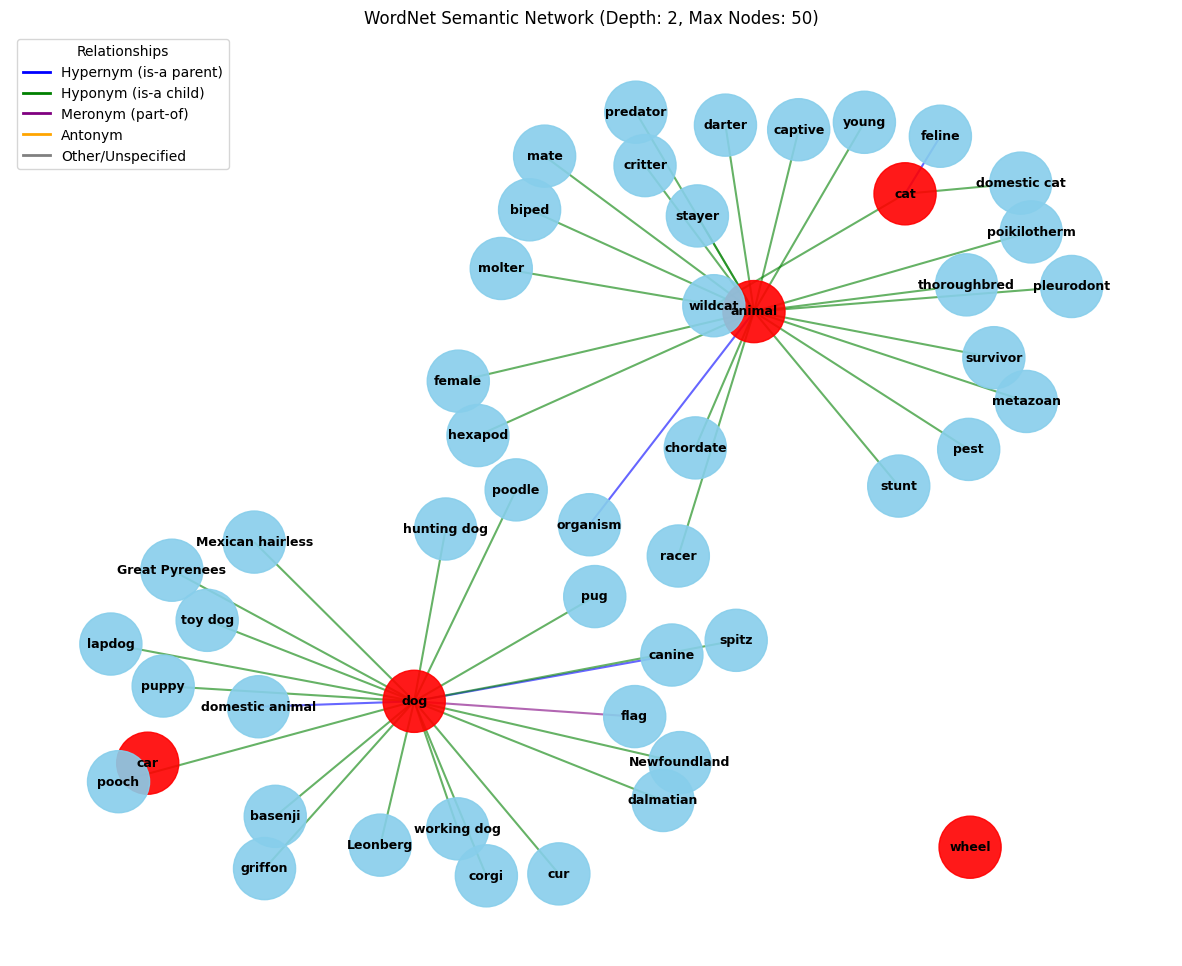

In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
from nltk.corpus import wordnet as wn
from collections import deque

# --- Configuration ---
START_WORDS = ["dog", "cat", "animal", "car", "wheel"]
MAX_DEPTH = 2  # How many steps away from the start words to explore
MAX_NODES = 50 # Limit the total number of nodes for readability
RELATIONSHIPS_TO_EXPLORE = [
    'hypernyms',    # More general concept (is-a)
    'hyponyms',     # More specific concept (is-a)
    'part_meronyms', # Part of something (has-a part)
    'substance_meronyms', # Made of something
    'member_meronyms', # Member of a group
    'antonyms'      # Opposite meaning
]

# --- Graph Construction ---
G = nx.Graph()
visited_synsets = set()
queue = deque()

# Initialize queue with starting words
for word_str in START_WORDS:
    synsets = wn.synsets(word_str)
    if synsets:
        # Take the most common synset (first one)
        start_synset = synsets[0]
        queue.append((start_synset, 0)) # (synset, current_depth)
        G.add_node(start_synset.name(), label=word_str, type='start')
        visited_synsets.add(start_synset)
    else:
        print(f"Warning: '{word_str}' not found in WordNet.")

node_count = len(G.nodes())

while queue and node_count < MAX_NODES:
    current_synset, depth = queue.popleft()

    if depth >= MAX_DEPTH:
        continue

    current_label = current_synset.lemmas()[0].name().replace('_', ' ') # Get a readable label

    for rel_type in RELATIONSHIPS_TO_EXPLORE:
        related_synsets = []
        if hasattr(current_synset, rel_type):
            # Get the method for the relationship type
            rel_method = getattr(current_synset, rel_type)
            related_synsets = rel_method()

        for related_synset in related_synsets:
            if node_count >= MAX_NODES:
                break

            related_label = related_synset.lemmas()[0].name().replace('_', ' ')

            # Add node if not already present
            if related_synset.name() not in G:
                G.add_node(related_synset.name(), label=related_label, type='related')
                node_count += 1

            # Add edge
            G.add_edge(current_synset.name(), related_synset.name(), relation=rel_type)

            # Add to queue for further exploration if not visited and within depth
            if related_synset not in visited_synsets and depth + 1 < MAX_DEPTH:
                queue.append((related_synset, depth + 1))
                visited_synsets.add(related_synset)

# --- Visualization ---
plt.figure(figsize=(15, 12))

# Get node labels for display
node_labels = {node: G.nodes[node]['label'] for node in G.nodes()}

# Assign colors based on node type
node_colors = []
for node in G.nodes():
    if G.nodes[node]['type'] == 'start':
        node_colors.append('red')
    else:
        node_colors.append('skyblue')

# Assign edge colors based on relationship type
edge_colors = []
for u, v, data in G.edges(data=True):
    rel = data['relation']
    if rel == 'hypernyms':
        edge_colors.append('blue')
    elif rel == 'hyponyms':
        edge_colors.append('green')
    elif 'meronyms' in rel:
        edge_colors.append('purple')
    elif rel == 'antonyms':
        edge_colors.append('orange')
    else:
        edge_colors.append('gray')

# Use a spring layout for better visual separation
pos = nx.spring_layout(G, k=0.5, iterations=50) # k adjusts optimal distance between nodes

nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=2000, alpha=0.9)
nx.draw_networkx_edges(G, pos, edge_color=edge_colors, width=1.5, alpha=0.6)
nx.draw_networkx_labels(G, pos, labels=node_labels, font_size=9, font_weight='bold')

# Create a legend for edge colors
legend_elements = [
    plt.Line2D([0], [0], color='blue', lw=2, label='Hypernym (is-a parent)'),
    plt.Line2D([0], [0], color='green', lw=2, label='Hyponym (is-a child)'),
    plt.Line2D([0], [0], color='purple', lw=2, label='Meronym (part-of)'),
    plt.Line2D([0], [0], color='orange', lw=2, label='Antonym'),
    plt.Line2D([0], [0], color='gray', lw=2, label='Other/Unspecified')
]
plt.legend(handles=legend_elements, loc='upper left', title="Relationships")

plt.title(f"WordNet Semantic Network (Depth: {MAX_DEPTH}, Max Nodes: {MAX_NODES})")
plt.axis('off') # Hide axes
plt.show()

In [ ]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [ ]:
import nltk
from nltk.corpus import wordnet as wn
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from nltk.tag import pos_tag
nltk.download('averaged_perceptron_tagger_eng')
# --- 1. Download necessary NLTK data (run once) ---
# This block ensures all required NLTK data is present.
# If you run this code for the first time, it will download these.
# Note: Without try-except, if a download fails, the script will stop.
print("Checking NLTK data...")
nltk.download('wordnet', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('wordnet_ic', quiet=True) # For information content measures

# Load information content corpus globally
from nltk.corpus import wordnet_ic
brown_ic = wordnet_ic.ic('ic-brown.dat') # This will fail if wordnet_ic wasn't downloaded

print("NLTK data check complete.")

# --- 2. Preprocessing Logic (Inline) ---

# Helper to map NLTK POS tags to WordNet POS tags
def _get_wordnet_pos(tag):
    if tag.startswith('J'):
        return wn.ADJ
    elif tag.startswith('V'):
        return wn.VERB
    elif tag.startswith('N'):
        return wn.NOUN
    elif tag.startswith('R'):
        return wn.ADV
    else:
        return None

# Helper to get synsets for a word
def _get_synsets_for_word(word, pos=None):
    if pos:
        return wn.synsets(word, pos=pos)
    else:
        return wn.synsets(word)

# Helper to get the "best" (first) synset for a word
def _get_best_synset(word, pos=None):
    synsets = _get_synsets_for_word(word, pos)
    if synsets:
        return synsets[0]
    return None

# --- 3. Semantic Similarity Logic (Inline) ---

# Helper to calculate similarity
def _calculate_similarity(synset1, synset2, measure='path'):
    if not synset1 or not synset2:
        return 0.0

    if measure == 'path':
        return synset1.path_similarity(synset2)
    elif measure == 'lch':
        return synset1.lch_similarity(synset2)
    elif measure == 'wup':
        return synset1.wup_similarity(synset2)
    elif measure == 'res':
        return synset1.res_similarity(synset2, brown_ic)
    elif measure == 'lin':
        return synset1.lin_similarity(synset2, brown_ic)
    elif measure == 'jcn':
        return synset1.jcn_similarity(synset2, brown_ic)
    else:
        # This will raise an error if an unknown measure is passed
        raise ValueError(f"Unknown similarity measure: {measure}")

# --- 4. Main QA System Logic (Linear Flow) ---

print("\nWelcome to the WordNet QA System!")
print("I can answer questions about definitions, synonyms, types, and semantic similarity.")
print("Type 'quit' or 'exit' to stop.")

lemmatizer = WordNetLemmatizer()

# List of example questions
questions = [
    "What is a dog?",
    "Define cat.",
    "What is the synonym of happy?",
    "What is the same as car?",
    "What are types of vehicles?",
    "What kinds of fruit are there?",
    "A car is a type of what?",
    "What is the category of a tree?",
    "How similar are car and automobile?",
    "Similarity between good and bad?",
    "How similar are dog and cat?",
    "How similar are run and walk?",
    "How similar are tree and plant?",
    "Tell me about the weather.", # Example of a question it can't answer well
    "What is the capital of France?" # Another example it can't answer
]

# Process example questions
for q_text in questions:
    print(f"\nQ: {q_text}")

    # --- Preprocessing for the current question ---
    tokens = word_tokenize(q_text.lower())
    tagged_tokens = pos_tag(tokens)

    lemmas = []
    for word, tag in tagged_tokens:
        wn_pos = _get_wordnet_pos(tag)
        if wn_pos:
            lemmas.append(lemmatizer.lemmatize(word, wn_pos))
        else:
            lemmas.append(lemmatizer.lemmatize(word)) # Default to noun

    # --- Intent Recognition and Answering Logic ---
    answer = "I can only answer questions about definitions, synonyms, types, and similarity using WordNet." # Default answer

    if "what is" in q_text.lower() or "define" in q_text.lower():
        # Handle definition question
        target_word = None
        for lemma in lemmas:
            if _get_synsets_for_word(lemma):
                target_word = lemma
                break

        if target_word:
            best_synset = _get_best_synset(target_word)
            if best_synset:
                answer = f"A '{target_word}' is: {best_synset.definition()}"
            else:
                answer = f"Could not find a definition for '{target_word}' in WordNet."
        else:
            answer = "Please specify what you want me to define."

    elif "synonym of" in q_text.lower() or "same as" in q_text.lower():
        # Handle synonym question
        target_word = None
        for lemma in lemmas:
            if _get_synsets_for_word(lemma):
                target_word = lemma
                break

        if target_word:
            best_synset = _get_best_synset(target_word)
            if best_synset:
                synonym_lemmas = best_synset.lemmas()
                synonyms = [lemma_obj.name().replace('_', ' ') for lemma_obj in synonym_lemmas if lemma_obj.name() != target_word]
                if synonyms:
                    answer = f"Synonyms for '{target_word}': {', '.join(sorted(list(set(synonyms))))}"
                else:
                    answer = f"No distinct synonyms found for '{target_word}' in this sense."
            else:
                answer = f"Could not find '{target_word}' in WordNet."
        else:
            answer = "Please specify a word to find synonyms for."

    elif "types of" in q_text.lower() or "kinds of" in q_text.lower():
        # Handle hyponym question
        target_word = None
        for lemma in lemmas:
            if _get_synsets_for_word(lemma, pos=wn.NOUN):
                target_word = lemma
                break

        if target_word:
            best_synset = _get_best_synset(target_word, pos=wn.NOUN)
            if best_synset:
                hyponyms = best_synset.hyponyms()
                if hyponyms:
                    hyponym_names = [h.lemmas()[0].name().replace('_', ' ') for h in hyponyms]
                    answer = f"Types of '{target_word}': {', '.join(sorted(list(set(hyponym_names))))}"
                else:
                    answer = f"No specific types (hyponyms) found for '{target_word}'."
            else:
                answer = f"Could not find '{target_word}' as a noun in WordNet."
        else:
            answer = "Please specify a word to find types of."

    elif "is a type of" in q_text.lower() or "category of" in q_text.lower():
        # Handle hypernym question
        target_word = None
        for lemma in lemmas:
            if _get_synsets_for_word(lemma, pos=wn.NOUN):
                target_word = lemma
                break

        if target_word:
            best_synset = _get_best_synset(target_word, pos=wn.NOUN)
            if best_synset:
                hypernyms = best_synset.hypernyms()
                if hypernyms:
                    hypernym_names = [h.lemmas()[0].name().replace('_', ' ') for h in hypernyms]
                    answer = f"'{target_word}' is a type of: {', '.join(sorted(list(set(hypernym_names))))}"
                else:
                    answer = f"No broader categories (hypernyms) found for '{target_word}'."
            else:
                answer = f"Could not find '{target_word}' as a noun in WordNet."
        else:
            answer = "Please specify a word to find its category."

    elif "how similar are" in q_text.lower() or "similarity between" in q_text.lower():
        # Handle similarity question
        words_to_compare = []
        for i, lemma in enumerate(lemmas):
            if lemma not in ["how", "similar", "are", "and", "between", "the", "what", "is", "of"]:
                if _get_synsets_for_word(lemma):
                    words_to_compare.append(lemma)
            if len(words_to_compare) >= 2:
                break

        words_to_compare = list(set(words_to_compare))
        if len(words_to_compare) < 2:
            all_lemmas_with_synsets = [l for l in lemmas if _get_synsets_for_word(l) and l not in ["how", "similar", "are", "and", "between", "the", "what", "is", "of"]]
            if len(all_lemmas_with_synsets) >= 2:
                words_to_compare = all_lemmas_with_synsets[:2]
            else:
                answer = "Please ask about the similarity between two specific words (e.g., 'How similar are car and automobile?')."

        if len(words_to_compare) >= 2:
            word1 = words_to_compare[0]
            word2 = words_to_compare[1]

            synset1 = _get_best_synset(word1)
            synset2 = _get_best_synset(word2)

            if synset1 and synset2:
                results = []
                measures = ['path', 'lch', 'wup', 'res', 'lin', 'jcn'] # All measures, assuming brown_ic is loaded
                for measure in measures:
                    similarity = _calculate_similarity(synset1, synset2, measure=measure)
                    if similarity is not None:
                        results.append(f"{measure.upper()}: {similarity:.2f}")

                if results:
                    answer = f"Similarity between '{word1}' and '{word2}': {'; '.join(results)}"
                else:
                    answer = f"Could not calculate similarity for '{word1}' and '{word2}' with available measures."
            else:
                answer = f"Could not find synsets for one or both words: '{word1}', '{word2}'."

    print(f"A: {answer}")

print("\n--- Interactive Mode ---")
while True:
    user_question = input("\nEnter your question: ")
    if user_question.lower() in ['quit', 'exit']:
        print("Exiting QA system. Goodbye!")
        break

    q_text = user_question # Use user_question as q_text for consistency

    # --- Preprocessing for the current question ---
    tokens = word_tokenize(q_text.lower())
    tagged_tokens = pos_tag(tokens)

    lemmas = []
    for word, tag in tagged_tokens:
        wn_pos = _get_wordnet_pos(tag)
        if wn_pos:
            lemmas.append(lemmatizer.lemmatize(word, wn_pos))
        else:
            lemmas.append(lemmatizer.lemmatize(word)) # Default to noun

    # --- Intent Recognition and Answering Logic ---
    answer = "I can only answer questions about definitions, synonyms, types, and similarity using WordNet." # Default answer

    if "what is" in q_text.lower() or "define" in q_text.lower():
        # Handle definition question
        target_word = None
        for lemma in lemmas:
            if _get_synsets_for_word(lemma):
                target_word = lemma
                break

        if target_word:
            best_synset = _get_best_synset(target_word)
            if best_synset:
                answer = f"A '{target_word}' is: {best_synset.definition()}"
            else:
                answer = f"Could not find a definition for '{target_word}' in WordNet."
        else:
            answer = "Please specify what you want me to define."

    elif "synonym of" in q_text.lower() or "same as" in q_text.lower():
        # Handle synonym question
        target_word = None
        for lemma in lemmas:
            if _get_synsets_for_word(lemma):
                target_word = lemma
                break

        if target_word:
            best_synset = _get_best_synset(target_word)
            if best_synset:
                synonym_lemmas = best_synset.lemmas()
                synonyms = [lemma_obj.name().replace('_', ' ') for lemma_obj in synonym_lemmas if lemma_obj.name() != target_word]
                if synonyms:
                    answer = f"Synonyms for '{target_word}': {', '.join(sorted(list(set(synonyms))))}"
                else:
                    answer = f"No distinct synonyms found for '{target_word}' in this sense."
            else:
                answer = f"Could not find '{target_word}' in WordNet."
        else:
            answer = "Please specify a word to find synonyms for."

    elif "types of" in q_text.lower() or "kinds of" in q_text.lower():
        # Handle hyponym question
        target_word = None
        for lemma in lemmas:
            if _get_synsets_for_word(lemma, pos=wn.NOUN):
                target_word = lemma
                break

        if target_word:
            best_synset = _get_best_synset(target_word, pos=wn.NOUN)
            if best_synset:
                hyponyms = best_synset.hyponyms()
                if hyponyms:
                    hyponym_names = [h.lemmas()[0].name().replace('_', ' ') for h in hyponyms]
                    answer = f"Types of '{target_word}': {', '.join(sorted(list(set(hyponym_names))))}"
                else:
                    answer = f"No specific types (hyponyms) found for '{target_word}'."
            else:
                answer = f"Could not find '{target_word}' as a noun in WordNet."
        else:
            answer = "Please specify a word to find types of."

    elif "is a type of" in q_text.lower() or "category of" in q_text.lower():
        # Handle hypernym question
        target_word = None
        for lemma in lemmas:
            if _get_synsets_for_word(lemma, pos=wn.NOUN):
                target_word = lemma
                break

        if target_word:
            best_synset = _get_best_synset(target_word, pos=wn.NOUN)
            if best_synset:
                hypernyms = best_synset.hypernyms()
                if hypernyms:
                    hypernym_names = [h.lemmas()[0].name().replace('_', ' ') for h in hypernyms]
                    answer = f"'{target_word}' is a type of: {', '.join(sorted(list(set(hypernym_names))))}"
                else:
                    answer = f"No broader categories (hypernyms) found for '{target_word}'."
            else:
                answer = f"Could not find '{target_word}' as a noun in WordNet."
        else:
            answer = "Please specify a word to find its category."

    elif "how similar are" in q_text.lower() or "similarity between" in q_text.lower():
        # Handle similarity question
        words_to_compare = []
        for i, lemma in enumerate(lemmas):
            if lemma not in ["how", "similar", "are", "and", "between", "the", "what", "is", "of"]:
                if _get_synsets_for_word(lemma):
                    words_to_compare.append(lemma)
            if len(words_to_compare) >= 2:
                break

        words_to_compare = list(set(words_to_compare))
        if len(words_to_compare) < 2:
            all_lemmas_with_synsets = [l for l in lemmas if _get_synsets_for_word(l) and l not in ["how", "similar", "are", "and", "between", "the", "what", "is", "of"]]
            if len(all_lemmas_with_synsets) >= 2:
                words_to_compare = all_lemmas_with_synsets[:2]
            else:
                answer = "Please ask about the similarity between two specific words (e.g., 'How similar are car and automobile?')."

        if len(words_to_compare) >= 2:
            word1 = words_to_compare[0]
            word2 = words_to_compare[1]

            synset1 = _get_best_synset(word1)
            synset2 = _get_best_synset(word2)

            if synset1 and synset2:
                results = []
                measures = ['path', 'lch', 'wup', 'res', 'lin', 'jcn']
                for measure in measures:
                    similarity = _calculate_similarity(synset1, synset2, measure=measure)
                    if similarity is not None:
                        results.append(f"{measure.upper()}: {similarity:.2f}")

                if results:
                    answer = f"Similarity between '{word1}' and '{word2}': {'; '.join(results)}"
                else:
                    answer = f"Could not calculate similarity for '{word1}' and '{word2}' with available measures."
            else:
                answer = f"Could not find synsets for one or both words: '{word1}', '{word2}'."

    print(f"A: {answer}")

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


Checking NLTK data...
NLTK data check complete.

Welcome to the WordNet QA System!
I can answer questions about definitions, synonyms, types, and semantic similarity.
Type 'quit' or 'exit' to stop.

Q: What is a dog?
A: A 'be' is: a light strong brittle grey toxic bivalent metallic element

Q: Define cat.
A: A 'define' is: determine the essential quality of

Q: What is the synonym of happy?
A: A 'be' is: a light strong brittle grey toxic bivalent metallic element

Q: What is the same as car?
A: A 'be' is: a light strong brittle grey toxic bivalent metallic element

Q: What are types of vehicles?
A: No specific types (hyponyms) found for 'be'.

Q: What kinds of fruit are there?
A: Types of 'kinds': antitype, art form, brand, color, description, flavor, genre, genus, like, manner, model, species, stripe, style, type

Q: A car is a type of what?
A: 'a' is a type of: metric linear unit

Q: What is the category of a tree?
A: A 'be' is: a light strong brittle grey toxic bivalent metallic ele

KeyboardInterrupt: Interrupted by user

In [ ]:
import re

class SimpleRBMT:
    def __init__(self):
        # Our core dictionary for word-to-word translation
        self.dictionary = {
            "hello": "bonjour",
            "hi": "salut",
            "how": "comment",
            "are": "êtes",  # Simplified, doesn't handle "are" for "you" plural/formal
            "you": "vous",
            "i": "je",
            "am": "suis",
            "fine": "bien",
            "thank": "merci",
            "thanks": "merci",
            "good": "bon",
            "morning": "matin",
            "evening": "soir",
            "night": "nuit",
            "a": "un",
            "an": "un",
            "the": "le", # Very simplified, doesn't handle la, les, l'
            "cat": "chat",
            "dog": "chien",
            "and": "et",
            "is": "est",
            "this": "ceci",
            "that": "cela",
            "my": "mon", # Simplified, doesn't handle ma, mes
            "name": "nom",
            "what": "quel",
            "your": "votre", # Simplified, doesn't handle ta, ton, tes, vos
            "is": "est",
            "beautiful": "belle", # Simplified, doesn't handle beau, beaux, belles
            "house": "maison",
            "big": "grand", # Simplified, doesn't handle grande, grands, grandes
            "small": "petit", # Simplified, doesn't handle petite, petits, petites
        }

        # Simple grammatical rules (very, very basic)
        # These are more like phrase-level replacements or reordering
        self.rules = [
            # Rule 1: "How are you?" -> "Comment allez-vous?" (idiomatic)
            (r"how are you\?", "comment allez-vous ?"),
            # Rule 2: "I am fine" -> "Je vais bien" (idiomatic)
            (r"i am fine", "je vais bien"),
            # Rule 3: "Thank you" -> "Merci" (idiomatic)
            (r"thank you", "merci"),
            # Rule 4: "Good morning" -> "Bonjour" (idiomatic)
            (r"good morning", "bonjour"),
            # Rule 5: "Good evening" -> "Bonsoir" (idiomatic)
            (r"good evening", "bonsoir"),
            # Rule 6: "Good night" -> "Bonne nuit" (idiomatic)
            (r"good night", "bonne nuit"),
            # Rule 7: "What is your name?" -> "Quel est votre nom ?"
            (r"what is your name\?", "quel est votre nom ?"),
            # Rule 8: "My name is X" -> "Mon nom est X"
            (r"my name is (\w+)", r"mon nom est \1"),
            # Rule 9: Adjective placement (English: big house, French: maison grande)
            # This is a very crude attempt and won't work for all adjectives
            (r"(a|an|the) (big|small|beautiful) (cat|dog|house)", r"\1 \3 \2"),
        ]

    def translate(self, text):
        # 1. Preprocessing: Convert to lowercase and remove extra spaces
        original_text = text
        text = text.lower().strip()

        # 2. Apply grammatical rules (phrase-level replacements/reordering)
        # We apply these first because they often involve specific phrases
        for pattern, replacement in self.rules:
            # Use re.sub for regex-based replacements
            text = re.sub(pattern, replacement, text)

        # 3. Tokenization: Split the text into words
        # We use re.findall to keep punctuation separate for now
        words = re.findall(r'\b\w+\b|[^\s\w]', text)

        translated_words = []
        for word in words:
            # 4. Dictionary Lookup: Translate individual words
            # We check if the word is in our dictionary, otherwise keep it as is
            translated_word = self.dictionary.get(word, word)
            translated_words.append(translated_word)

        # 5. Post-processing: Join words back into a sentence
        # This is a very basic join and might not handle punctuation perfectly
        translated_sentence = " ".join(translated_words)

        # Basic capitalization for the start of the sentence
        if translated_sentence:
            translated_sentence = translated_sentence[0].upper() + translated_sentence[1:]

        # A very crude attempt to fix spacing around question marks
        translated_sentence = translated_sentence.replace(" ?", "?")
        translated_sentence = translated_sentence.replace(" !", "!")
        translated_sentence = translated_sentence.replace(" .", ".")
        translated_sentence = translated_sentence.replace(" ,", ",")

        return translated_sentence

# --- Test the translator ---
translator = SimpleRBMT()

english_sentences = [
    "Hello, how are you?",
    "I am fine, thank you.",
    "Good morning!",
    "Good evening.",
    "Good night.",
    "What is your name?",
    "My name is Alice.",
    "This is a cat.",
    "That is a big dog.",
    "A beautiful house.",
    "I am a small cat.",
    "The dog and the cat.",
    "Hi!",
    "Thanks!",
]

print("--- English to French Translation (RBMT) ---")
for sentence in english_sentences:
    translated = translator.translate(sentence)
    print(f"EN: {sentence}")
    print(f"FR: {translated}\n")

# Example of a sentence it won't handle well due to missing rules/vocabulary
print("\n--- Examples of limitations ---")
print(f"EN: I like to eat apples.")
print(f"FR: {translator.translate('I like to eat apples.')}\n") # "Je like to eat apples." - 'like', 'to', 'eat', 'apples' not in dict
print(f"EN: The big red car.")
print(f"FR: {translator.translate('The big red car.')}\n") # "Le big red car." - 'red', 'car' not in dict, adjective order wrong
print(f"EN: Are you happy?")
print(f"FR: {translator.translate('Are you happy?')}\n") # "Êtes vous happy?" - 'happy' not in dict, 'êtes' is wrong for 'you' singular

In [ ]:
def simple_machine_translator(english_sentence):
    """
    A very basic machine translator that translates English words to Spanish
    based on a predefined dictionary.
    """
    # Our "translation model" - a simple dictionary
    translation_dictionary = {
        "hello": "hola",
        "world": "mundo",
        "how": "cómo",
        "are": "estás",  # Simplified for "you are"
        "you": "tú",
        "i": "yo",
        "am": "soy",
        "fine": "bien",
        "thank": "gracias",
        "good": "bueno",
        "morning": "mañana",
        "the": "el",
        "cat": "gato",
        "is": "es",
        "on": "en",
        "table": "mesa",
        "a": "un",
        "dog": "perro",
        "eat": "comer",
        "apple": "manzana",
        # Add more words as needed
    }

    # Convert the sentence to lowercase to match dictionary keys
    words = english_sentence.lower().split()
    translated_words = []

    for word in words:
        # Look up the word in our dictionary
        if word in translation_dictionary:
            translated_words.append(translation_dictionary[word])
        else:
            # If we don't know the word, keep it as is or mark it
            translated_words.append(f"[{word}]") # Indicate untranslated words

    # Join the translated words back into a sentence
    spanish_sentence = " ".join(translated_words)
    return spanish_sentence

# --- Test Cases ---
print("--- Simple Machine Translator ---")

english_input1 = "Hello world"
spanish_output1 = simple_machine_translator(english_input1)
print(f"English: '{english_input1}'")
print(f"Spanish: '{spanish_output1}'\n")

english_input2 = "How are you"
spanish_output2 = simple_machine_translator(english_input2)
print(f"English: '{english_input2}'")
print(f"Spanish: '{spanish_output2}'\n")

english_input3 = "I am fine thank you"
spanish_output3 = simple_machine_translator(english_input3)
print(f"English: '{english_input3}'")
print(f"Spanish: '{spanish_output3}'\n")

english_input4 = "The cat is on the table"
spanish_output4 = simple_machine_translator(english_input4)
print(f"English: '{english_input4}'")
print(f"Spanish: '{spanish_output4}'\n")

english_input5 = "A dog will eat an apple" # 'will' and 'an' are not in dictionary
spanish_output5 = simple_machine_translator(english_input5)
print(f"English: '{english_input5}'")
print(f"Spanish: '{spanish_output5}'\n")

english_input6 = "Good morning"
spanish_output6 = simple_machine_translator(english_input6)
print(f"English: '{english_input6}'")
print(f"Spanish: '{spanish_output6}'\n")

In [ ]:
import subprocess
import sys

def install_and_import(package):
    """
    Installs a package if it's not already installed, then imports it.
    """
    try:
        __import__(package)
        print(f"'{package}' is already installed.")
    except ImportError:
        print(f"'{package}' not found. Installing...")
        try:
            subprocess.check_call([sys.executable, "-m", "pip", "install", package])
            print(f"Successfully installed '{package}'.")
            __import__(package)
        except Exception as e:
            print(f"Failed to install '{package}': {e}")
            sys.exit(1)

# --- 1. Install necessary libraries ---
# We need transformers for the models, torch as the backend, and sentencepiece for tokenization.
install_and_import("transformers")
install_and_import("torch")
install_and_import("sentencepiece") # Required by many Transformer models

# Now that we're sure they're installed, we can import them
from transformers import pipeline, AutoTokenizer, AutoModelForSeq2SeqLM

print("\n--- Machine Translation Demo using Hugging Face Transformers ---")

# --- 2. Simple English to French Translation (MarianMT) ---
print("\n--- Part 1: English to French Translation (Helsinki-NLP/opus-mt-en-fr) ---")
print("This model is specialized for English-French translation.")

try:
    # Load the pre-trained English-to-French translation pipeline
    # This uses a MarianMT model, which is an encoder-decoder Transformer.
    # The 'pipeline' abstraction makes it very easy to use.
    translator_en_fr = pipeline("translation_en_to_fr", model="Helsinki-NLP/opus-mt-en-fr")
    print("Model 'Helsinki-NLP/opus-mt-en-fr' loaded successfully.")

    def translate_en_to_fr(text):
        """Translates English text to French using the loaded pipeline."""
        if not text.strip():
            return "Input text is empty."
        try:
            # The pipeline returns a list of dictionaries, we extract the 'translation_text'
            result = translator_en_fr(text)
            return result[0]['translation_text']
        except Exception as e:
            return f"Error during translation: {e}"

    # Test cases
    english_sentences = [
        "Hello, how are you doing today?",
        "Machine translation is a fascinating field in Natural Language Processing.",
        "The quick brown fox jumps over the lazy dog.",
        "I love programming in Python.",
        "What is the capital of France?"
    ]

    for sentence in english_sentences:
        french_translation = translate_en_to_fr(sentence)
        print(f"\nEnglish: {sentence}")
        print(f"French:  {french_translation}")

    # User input loop
    print("\n--- Try your own English sentences (type 'quit' to exit) ---")
    while True:
        user_input = input("Enter English text: ")
        if user_input.lower() == 'quit':
            break
        translated_text = translate_en_to_fr(user_input)
        print(f"French:  {translated_text}")

except Exception as e:
    print(f"Could not load or use 'Helsinki-NLP/opus-mt-en-fr' model: {e}")
    print("Skipping English to French translation part.")


# --- 3. Multi-lingual Translation (mBART-50) ---
print("\n\n--- Part 2: Multi-lingual Translation (facebook/mbart-large-50-many-to-many-mmt) ---")
print("This model can translate between many different languages.")
print("It requires specifying source and target language codes.")

try:
    # Load tokenizer and model for mBART-50
    # This model is larger and more versatile, supporting 50 languages.
    # It's an encoder-decoder Transformer.
    tokenizer_mbart = AutoTokenizer.from_pretrained("facebook/mbart-large-50-many-to-many-mmt")
    model_mbart = AutoModelForSeq2SeqLM.from_pretrained("facebook/mbart-large-50-many-to-many-mmt")
    print("Model 'facebook/mbart-large-50-many-to-many-mmt' loaded successfully.")

    # Define a dictionary of common language codes for convenience
    LANG_CODES = {
        "en": "en_XX",  # English
        "fr": "fr_XX",  # French
        "de": "de_DE",  # German
        "es": "es_XX",  # Spanish
        "it": "it_IT",  # Italian
        "zh": "zh_CN",  # Chinese (Simplified)
        "ja": "ja_XX",  # Japanese
        "ru": "ru_RU",  # Russian
        "ar": "ar_AR",  # Arabic
        "hi": "hi_IN",  # Hindi
        "pt": "pt_XX",  # Portuguese
        "ko": "ko_KR",  # Korean
        # You can find a full list in the model's documentation or tokenizer.lang_code_to_id
    }

    def translate_mbart(text, source_lang_code, target_lang_code):
        """
        Translates text using the mBART-50 model.
        Requires source and target language codes (e.g., 'en_XX', 'fr_XX').
        """
        if not text.strip():
            return "Input text is empty."
        if source_lang_code not in tokenizer_mbart.lang_code_to_id:
            return f"Invalid source language code: {source_lang_code}"
        if target_lang_code not in tokenizer_mbart.lang_code_to_id:
            return f"Invalid target language code: {target_lang_code}"

        try:
            # Set the source language for the tokenizer
            tokenizer_mbart.src_lang = source_lang_code

            # Encode the input text
            encoded_input = tokenizer_mbart(text, return_tensors="pt")

            # Generate translation tokens, forcing the beginning-of-sentence token
            # for the target language.
            generated_tokens = model_mbart.generate(
                **encoded_input,
                forced_bos_token_id=tokenizer_mbart.lang_code_to_id[target_lang_code],
                max_length=200 # Limit output length to prevent excessively long generations
            )

            # Decode the generated tokens back to human-readable text
            translated_text = tokenizer_mbart.batch_decode(generated_tokens, skip_special_tokens=True)[0]
            return translated_text
        except Exception as e:
            return f"Error during translation: {e}"

    # --- Test cases for mBART-50 ---
    print("\n--- mBART-50 Test Cases ---")

    # English to German
    text_en_de = "The weather is beautiful today. I love machine learning."
    translated_de = translate_mbart(text_en_de, LANG_CODES["en"], LANG_CODES["de"])
    print(f"\nEnglish (en_XX): {text_en_de}")
    print(f"German  (de_DE): {translated_de}")

    # German to Spanish
    text_de_es = "Das Wetter ist heute schön. Ich liebe maschinelles Lernen."
    translated_es = translate_mbart(text_de_es, LANG_CODES["de"], LANG_CODES["es"])
    print(f"\nGerman  (de_DE): {text_de_es}")
    print(f"Spanish (es_XX): {translated_es}")

    # French to Italian
    text_fr_it = "Bonjour, comment allez-vous? J'apprends l'italien."
    translated_it = translate_mbart(text_fr_it, LANG_CODES["fr"], LANG_CODES["it"])
    print(f"\nFrench  (fr_XX): {text_fr_it}")
    print(f"Italian (it_IT): {translated_it}")

    # User input loop for mBART-50
    print("\n--- Try your own multi-lingual translations (type 'quit' to exit) ---")
    print("Available language codes (short): en, fr, de, es, it, zh, ja, ru, ar, hi, pt, ko")
    print("Full list of supported codes: ", list(tokenizer_mbart.lang_code_to_id.keys()))

    while True:
        user_text = input("\nEnter text to translate: ")
        if user_text.lower() == 'quit':
            break

        user_src_lang = input("Enter source language code (e.g., 'en'): ").lower()
        if user_src_lang not in LANG_CODES:
            print("Invalid source language code. Please choose from the list.")
            continue

        user_tgt_lang = input("Enter target language code (e.g., 'fr'): ").lower()
        if user_tgt_lang not in LANG_CODES:
            print("Invalid target language code. Please choose from the list.")
            continue

        src_code = LANG_CODES[user_src_lang]
        tgt_code = LANG_CODES[user_tgt_lang]

        translated_text = translate_mbart(user_text, src_code, tgt_code)
        print(f"Translated ({user_src_lang} -> {user_tgt_lang}): {translated_text}")

except Exception as e:
    print(f"Could not load or use 'facebook/mbart-large-50-many-to-many-mmt' model: {e}")
    print("Skipping multi-lingual translation part.")

print("\n--- Demo Finished ---")

In [ ]:
import re
# Rule Based Machine Translation (SMT)
class SimpleRBMT:
    def __init__(self):
        # Our core dictionary for word-to-word translation
        self.dictionary = {
            "hello": "bonjour",
            "hi": "salut",
            "how": "comment",
            "are": "êtes",  # Simplified, doesn't handle "are" for "you" plural/formal
            "you": "vous",
            "i": "je",
            "am": "suis",
            "fine": "bien",
            "thank": "merci",
            "thanks": "merci",
            "good": "bon",
            "morning": "matin",
            "evening": "soir",
            "night": "nuit",
            "a": "un",
            "an": "un",
            "the": "le", # Very simplified, doesn't handle la, les, l'
            "cat": "chat",
            "dog": "chien",
            "and": "et",
            "is": "est",
            "this": "ceci",
            "that": "cela",
            "my": "mon", # Simplified, doesn't handle ma, mes
            "name": "nom",
            "what": "quel",
            "your": "votre", # Simplified, doesn't handle ta, ton, tes, vos
            "is": "est",
            "beautiful": "belle", # Simplified, doesn't handle beau, beaux, belles
            "house": "maison",
            "big": "grand", # Simplified, doesn't handle grande, grands, grandes
            "small": "petit", # Simplified, doesn't handle petite, petits, petites
        }

        # Simple grammatical rules (very, very basic)
        # These are more like phrase-level replacements or reordering
        self.rules = [
            # Rule 1: "How are you?" -> "Comment allez-vous?" (idiomatic)
            (r"how are you\?", "comment allez-vous ?"),
            # Rule 2: "I am fine" -> "Je vais bien" (idiomatic)
            (r"i am fine", "je vais bien"),
            # Rule 3: "Thank you" -> "Merci" (idiomatic)
            (r"thank you", "merci"),
            # Rule 4: "Good morning" -> "Bonjour" (idiomatic)
            (r"good morning", "bonjour"),
            # Rule 5: "Good evening" -> "Bonsoir" (idiomatic)
            (r"good evening", "bonsoir"),
            # Rule 6: "Good night" -> "Bonne nuit" (idiomatic)
            (r"good night", "bonne nuit"),
            # Rule 7: "What is your name?" -> "Quel est votre nom ?"
            (r"what is your name\?", "quel est votre nom ?"),
            # Rule 8: "My name is X" -> "Mon nom est X"
            (r"my name is (\w+)", r"mon nom est \1"),
            # Rule 9: Adjective placement (English: big house, French: maison grande)
            # This is a very crude attempt and won't work for all adjectives
            (r"(a|an|the) (big|small|beautiful) (cat|dog|house)", r"\1 \3 \2"),
        ]

    def translate(self, text):
        # 1. Preprocessing: Convert to lowercase and remove extra spaces
        original_text = text
        text = text.lower().strip()

        # 2. Apply grammatical rules (phrase-level replacements/reordering)
        # We apply these first because they often involve specific phrases
        for pattern, replacement in self.rules:
            # Use re.sub for regex-based replacements
            text = re.sub(pattern, replacement, text)

        # 3. Tokenization: Split the text into words
        # We use re.findall to keep punctuation separate for now
        words = re.findall(r'\b\w+\b|[^\s\w]', text)

        translated_words = []
        for word in words:
            # 4. Dictionary Lookup: Translate individual words
            # We check if the word is in our dictionary, otherwise keep it as is
            translated_word = self.dictionary.get(word, word)
            translated_words.append(translated_word)

        # 5. Post-processing: Join words back into a sentence
        # This is a very basic join and might not handle punctuation perfectly
        translated_sentence = " ".join(translated_words)

        # Basic capitalization for the start of the sentence
        if translated_sentence:
            translated_sentence = translated_sentence[0].upper() + translated_sentence[1:]

        # A very crude attempt to fix spacing around question marks
        translated_sentence = translated_sentence.replace(" ?", "?")
        translated_sentence = translated_sentence.replace(" !", "!")
        translated_sentence = translated_sentence.replace(" .", ".")
        translated_sentence = translated_sentence.replace(" ,", ",")

        return translated_sentence

# --- Test the translator ---
translator = SimpleRBMT()

english_sentences = [
    "Hello, how are you?",
    "I am fine, thank you.",
    "Good morning!",
    "Good evening.",
    "Good night.",
    "What is your name?",
    "My name is Alice.",
    "This is a cat.",
    "That is a big dog.",
    "A beautiful house.",
    "I am a small cat.",
    "The dog and the cat.",
    "Hi!",
    "Thanks!",
]

print("--- English to French Translation (RBMT) ---")
for sentence in english_sentences:
    translated = translator.translate(sentence)
    print(f"EN: {sentence}")
    print(f"FR: {translated}\n")

# Example of a sentence it won't handle well due to missing rules/vocabulary
print("\n--- Examples of limitations ---")
print(f"EN: I like to eat apples.")
print(f"FR: {translator.translate('I like to eat apples.')}\n") # "Je like to eat apples." - 'like', 'to', 'eat', 'apples' not in dict
print(f"EN: The big red car.")
print(f"FR: {translator.translate('The big red car.')}\n") # "Le big red car." - 'red', 'car' not in dict, adjective order wrong
print(f"EN: Are you happy?")
print(f"FR: {translator.translate('Are you happy?')}\n") # "Êtes vous happy?" - 'happy' not in dict, 'êtes' is wrong for 'you' singular

In [ ]:
from collections import defaultdict
#Statistical Machine Translation (SMT)
class SimpleSMTConcept:
    def __init__(self, parallel_corpus):
        """
        Initializes with a parallel corpus.
        parallel_corpus: A list of tuples, where each tuple is (english_sentence, french_sentence).
        """
        self.parallel_corpus = parallel_corpus
        self.translation_probabilities = defaultdict(lambda: defaultdict(float))
        self._train_translation_probabilities()

    def _train_translation_probabilities(self):
        """
        A very simplified way to estimate P(French_word | English_word).
        This assumes a 1:1 word alignment for simplicity, which is not true in real SMT.
        In reality, we'd use algorithms like IBM Model 1 for word alignment.
        """
        # Count co-occurrences
        co_occurrence_counts = defaultdict(lambda: defaultdict(int))
        english_word_counts = defaultdict(int)

        for eng_sent, fr_sent in self.parallel_corpus:
            eng_words = eng_sent.lower().split()
            fr_words = fr_sent.lower().split()

            # For simplicity, we assume every English word can align with every French word
            # in the same sentence. This is a huge oversimplification but demonstrates the idea.
            for eng_word in eng_words:
                english_word_counts[eng_word] += 1
                for fr_word in fr_words:
                    co_occurrence_counts[eng_word][fr_word] += 1

        # Calculate probabilities: P(French_word | English_word) = Count(Eng, Fr) / Count(Eng)
        for eng_word, fr_word_counts in co_occurrence_counts.items():
            total_eng_occurrences = english_word_counts[eng_word]
            if total_eng_occurrences > 0:
                for fr_word, count in fr_word_counts.items():
                    self.translation_probabilities[eng_word][fr_word] = count / total_eng_occurrences

    def get_translation_probabilities(self, english_word):
        """
        Returns the probabilities of French words given an English word.
        """
        return self.translation_probabilities.get(english_word.lower(), {})

    def translate_sentence_word_by_word(self, english_sentence):
        """
        A very naive word-by-word translation using the highest probability.
        This ignores reordering, grammar, and context.
        """
        translated_words = []
        for eng_word in english_sentence.lower().split():
            possible_translations = self.get_translation_probabilities(eng_word)
            if possible_translations:
                # Pick the French word with the highest probability
                best_fr_word = max(possible_translations, key=possible_translations.get)
                translated_words.append(best_fr_word)
            else:
                translated_words.append(f"[{eng_word}]") # Indicate untranslated word
        return " ".join(translated_words)

# --- Example Usage ---

# A very small parallel corpus
# In a real SMT system, this would be millions of sentences.
corpus = [
    ("the cat sat on the mat", "le chat était assis sur le tapis"),
    ("a dog barked loudly", "un chien aboyait fort"),
    ("i like to eat apples", "j'aime manger des pommes"),
    ("the mat is red", "le tapis est rouge"),
    ("the cat is big", "le chat est grand"),
    ("i like big dogs", "j'aime les grands chiens"),
    ("the red apple", "la pomme rouge"),
    ("a big red cat", "un grand chat roux"), # Added 'roux' for 'red' to show ambiguity
]

smt_model = SimpleSMTConcept(corpus)

print("--- Word Translation Probabilities (P(French | English)) ---")
print(f"P(chat | cat): {smt_model.get_translation_probabilities('cat').get('chat', 0):.2f}")
print(f"P(le | the): {smt_model.get_translation_probabilities('the').get('le', 0):.2f}")
print(f"P(tapis | mat): {smt_model.get_translation_probabilities('mat').get('tapis', 0):.2f}")
print(f"P(rouge | red): {smt_model.get_translation_probabilities('red').get('rouge', 0):.2f}")
print(f"P(roux | red): {smt_model.get_translation_probabilities('red').get('roux', 0):.2f}") # Shows ambiguity
print(f"P(grand | big): {smt_model.get_translation_probabilities('big').get('grand', 0):.2f}")
print(f"P(chien | dog): {smt_model.get_translation_probabilities('dog').get('chien', 0):.2f}")
print(f"P(pommes | apples): {smt_model.get_translation_probabilities('apples').get('pommes', 0):.2f}")
print("-" * 40)

print("\n--- Naive Word-by-Word Translation ---")
sentences_to_translate = [
    "the cat sat on the mat",
    "i like big dogs",
    "the red apple",
    "a big red cat",
    "i eat a banana", # 'eat' and 'banana' are unknown
]

for eng_sent in sentences_to_translate:
    translated = smt_model.translate_sentence_word_by_word(eng_sent)
    print(f"EN: {eng_sent}")
    print(f"FR (naive): {translated}\n")

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, pipeline
import re
import string
import unicodedata
import warnings
import sys
import subprocess

# Suppress specific warnings from transformers library
warnings.filterwarnings("ignore", category=UserWarning, module="transformers")

# --- 1. Sample Data  ---
# This data is designed to be challenging, including:
# - Grammatical errors
# - Typographical errors
# - Informal language/slang
# - Ambiguity
# - Missing context
# - Direct translations that don't make sense in Hindi
# - Mixed case

english_sentences = [
    "Hey, how r u? I'm good.",
    "This is a gr8 day. The weather is so nice, like a dream.",
    "I wanna go outside and play.",
    "My frnd, John, he said he's coming. But he's always late, lol.",
    "I hope he brings the ball. We need to practice for the match next week.",
    "Our team is not very strong. We lost last time. It was a bad game.",
    "The coach was angry. He shouted at everyone. I felt sad.",
    "But we will try harder this time. We must win! This is important for our school.",
    "Everyone is watching us. No pressure, right? Just kidding.",
    "I'm a bit nervous. What if we lose again? Oh well, let's just do our best.",
    "John just texted. He's stuck in traffic. Classic John. I knew it.",
    "Maybe I'll just read a book until he arrives. Or maybe I'll clean my room.",
    "It's a mess. My mom will be happy if I clean it. She always complains about my room.",
    "She says it looks like a war zone. Haha. I should really clean it.",
    "But I'm lazy. So lazy. I'll do it tomorrow. Promise.",
    "For now, I'll just wait for John. Hope he comes soon. I'm bored. Very bored.",
    "What to do? Maybe I'll watch some TV. Or play a video game.",
    "Yeah, a video game sounds good. I'll play that new one. The one with the dragons.",
    "It's awesome. I love dragons. They are so cool. I wish I had a dragon.",
    "That would be amazing. I could fly anywhere. No traffic then! Haha.",
    "Okay, I'm getting carried away. Focus. John. Ball. Match. Win. That's the plan. Let's do this."
]

# These are the "ideal" human-translated reference sentences for evaluation
hindi_sentences_reference = [
    "नमस्ते, आप कैसे हैं? मैं ठीक हूँ।",
    "यह एक शानदार दिन है। मौसम बहुत सुहावना है, एक सपने जैसा।",
    "मैं बाहर जाकर खेलना चाहता हूँ।",
    "मेरा दोस्त, जॉन, उसने कहा कि वह आ रहा है। लेकिन वह हमेशा देर करता है, हाहा।",
    "मुझे उम्मीद है कि वह गेंद लाएगा। हमें अगले सप्ताह के मैच के लिए अभ्यास करना होगा।",
    "हमारी टीम बहुत मजबूत नहीं है। हम पिछली बार हार गए थे। वह एक बुरा खेल था।",
    "कोच गुस्सा था। उसने सब पर चिल्लाया। मुझे दुख हुआ।",
    "लेकिन हम इस बार और कड़ी कोशिश करेंगे। हमें जीतना होगा! यह हमारे स्कूल के लिए महत्वपूर्ण है।",
    "सब हमें देख रहे हैं। कोई दबाव नहीं, है ना? बस मज़ाक कर रहा हूँ।",
    "मैं थोड़ा घबराया हुआ हूँ। क्या होगा अगर हम फिर से हार गए? खैर, चलो बस अपना सर्वश्रेष्ठ करें।",
    "जॉन ने अभी टेक्स्ट किया। वह ट्रैफिक में फँसा हुआ है। हमेशा की तरह जॉन। मुझे पता था।",
    "शायद मैं उसके आने तक एक किताब पढ़ूँगा। या शायद मैं अपना कमरा साफ करूँगा।",
    "यह एक गड़बड़ है। मेरी माँ खुश होगी अगर मैं इसे साफ करूँ। वह हमेशा मेरे कमरे के बारे में शिकायत करती है।",
    "वह कहती है कि यह एक युद्ध क्षेत्र जैसा दिखता है। हाहा। मुझे इसे सच में साफ करना चाहिए।",
    "लेकिन मैं आलसी हूँ। बहुत आलसी। मैं इसे कल करूँगा। वादा।",
    "अभी के लिए, मैं बस जॉन का इंतजार करूँगा। उम्मीद है कि वह जल्द आएगा। मैं ऊब गया हूँ। बहुत ऊब गया हूँ।",
    "क्या करूँ? शायद मैं कुछ टीवी देखूँगा। या एक वीडियो गेम खेलूँगा।",
    "हाँ, एक वीडियो गेम अच्छा लगता है। मैं वह नया वाला खेलूँगा। ड्रेगन वाला।",
    "यह कमाल का है। मुझे ड्रेगन पसंद हैं। वे बहुत अच्छे हैं। काश मेरे पास एक ड्रैगन होता।",
    "वह अद्भुत होता। मैं कहीं भी उड़ सकता था। तब कोई ट्रैफिक नहीं! हाहा।",
    "ठीक है, मैं बहक रहा हूँ। ध्यान केंद्रित करो। जॉन। गेंद। मैच। जीत। यही योजना है। चलो यह करते हैं।"
]

# --- 2. NLP Preprocessing Function (English) ---
def preprocess_english(text):
    """
    Applies various NLP preprocessing techniques to English text.
    """
    # 1. Lowercasing
    text = text.lower()

    # 2. Expand Contractions (simple example, a full library like 'contractions' is better)
    # This map includes common informal spellings and contractions from the sample data.
    contractions_map = {
        "r u": "are you", "i'm": "i am", "wanna": "want to", "frnd": "friend",
        "gr8": "great", "lol": "laughing out loud", "haha": "laughing",
        "i'll": "i will", "he's": "he is", "it's": "it is", "we'll": "we will",
        "don't": "do not", "can't": "cannot", "won't": "will not", "didn't": "did not",
        "isn't": "is not", "aren't": "are not", "wasn't": "was not", "weren't": "were not",
        "hasn't": "has not", "haven't": "have not", "hadn't": "had not", "wouldn't": "would not",
        "shouldn't": "should not", "couldn't": "could not", "mustn't": "must not",
        "you're": "you are", "they're": "they are", "we're": "we are", "that's": "that is",
        "what's": "what is", "where's": "where is", "who's": "who is", "how's": "how is",
        "y'all": "you all", "gonna": "going to", "gotta": "got to", "lemme": "let me",
        "kinda": "kind of", "sorta": "sort of", "ain't": "am not" # or 'is not', 'are not', etc.
    }
    for contraction, expansion in contractions_map.items():
        # Use word boundaries to avoid replacing parts of words (e.g., 'frnd' in 'friendly')
        # This is a simple regex, for complex cases, a dedicated library is better.
        text = re.sub(r'\b' + re.escape(contraction) + r'\b', expansion, text)

    # 3. Remove Punctuation (keep some for sentence structure, but simplify)
    # We'll keep periods, question marks, exclamation marks for sentence splitting later if needed
    # This regex removes all punctuation except alphanumeric characters, spaces, and .?!
    text = re.sub(r'[^\w\s.?!]', '', text)

    # 4. Remove Extra Whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    # 5. Remove Emojis (if any, not in this sample but good practice)
    emoji_pattern = re.compile(
        "["
        "\U0001F600-\U0001F64F"  # emoticons
        "\U0001F300-\U0001F5FF"  # symbols & pictographs
        "\U0001F680-\U0001F6FF"  # transport & map symbols
        "\U0001F1E0-\U0001F1FF"  # flags (iOS)
        "\U00002702-\U000027B0"
        "\U000024C2-\U0001F251"
        "]+", flags=re.UNICODE
    )
    text = emoji_pattern.sub(r'', text)

    # 6. Normalization (e.g., unicode normalization)
    text = unicodedata.normalize('NFKC', text)

    return text

# --- 3. NLP Post-processing Function (Hindi) ---
def postprocess_hindi(text):
    """
    Applies various NLP post-processing techniques to Hindi text.
    """
    # 1. Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # 2. Normalize Devanagari characters (NFKC is generally good for this)
    text = unicodedata.normalize('NFKC', text)

    # 3. Ensure correct punctuation (e.g., replace English period with Devanagari पूर्ण विराम '।')
    # This model often outputs English punctuation, so we convert.
    text = text.replace('.', '।') # Replace English period with Hindi Purn Viram
    # Ensure no double purn viram or purn viram followed by other punctuation
    text = text.replace('।।', '।')
    text = text.replace('।?', '?')
    text = text.replace('।!', '!')

    # 4. Handle common translation quirks (model specific refinements)
    # These are examples based on observing common outputs from this model.
    text = text.replace("हँसते हुए", "हाहा") # Often a more natural translation for 'lol' or 'haha'
    text = text.replace("क्लाシック जॉन", "हमेशा की तरह जॉन") # Refine a direct translation
    text = text.replace("ओह ठीक है", "खैर") # More natural phrasing
    text = text.replace("क्या करें", "क्या करूँ") # Correcting verb conjugation for 'I'
    text = text.replace("शायद मैं", "शायद मैं") # Ensure correct spacing if any issues

    return text

# --- 4. Main Translation Process ---
def translate_english_to_hindi(english_sentences, hindi_sentences_reference):

    print("--- Starting English to Hindi Translation ---")

    # --- 4.1. Apply Preprocessing to English Sentences ---
    print("\n--- Applying Preprocessing to English Sentences ---")
    preprocessed_english_sentences = [preprocess_english(s) for s in english_sentences]

    for i, (original, preprocessed) in enumerate(zip(english_sentences, preprocessed_english_sentences)):
        print(f"Original English [{i+1}]: {original}")
        print(f"Preprocessed English [{i+1}]: {preprocessed}\n")

    # --- 4.2. Load Pre-trained Machine Translation Model ---
    print("\n--- Loading Pre-trained Translation Model (Helsinki-NLP/opus-mt-en-hi) ---")
    model_name = "Helsinki-NLP/opus-mt-en-hi"
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

    # Create a translation pipeline for convenience
    # Use GPU if available, otherwise CPU (-1)
    device = 0 if torch.cuda.is_available() else -1
    translator = pipeline("translation", model=model, tokenizer=tokenizer,
                          src_lang="en", tgt_lang="hi", device=device)
    print(f"Model loaded. Using device: {'GPU' if device == 0 else 'CPU'}")

    # --- 4.3. Translate Preprocessed English Sentences ---
    print("\n--- Translating Preprocessed English Sentences to Hindi ---")
    translated_sentences_raw = []
    for i, sentence in enumerate(preprocessed_english_sentences):
        # The pipeline expects a list of strings, even for a single sentence
        translation_output = translator(sentence, max_length=128) # Limit max_length to prevent excessively long outputs
        translated_text = translation_output[0]['translation_text']
        translated_sentences_raw.append(translated_text)
        print(f"Preprocessed English [{i+1}]: {sentence}")
        print(f"Translated Hindi (Raw) [{i+1}]: {translated_text}\n")

    # --- 4.4. Apply Post-processing to Hindi Translations ---
    print("\n--- Applying Post-processing to Hindi Translations ---")
    final_hindi_translations = [postprocess_hindi(s) for s in translated_sentences_raw]

    for i, (raw, final) in enumerate(zip(translated_sentences_raw, final_hindi_translations)):
        print(f"Translated Hindi (Raw) [{i+1}]: {raw}")
        print(f"Translated Hindi (Post-processed) [{i+1}]: {final}\n")

    # --- 4.5. Evaluation (No BLEU Score - as requested) ---
    print("\n--- Evaluation (No BLEU Score calculation as per request) ---")
    print("Skipping BLEU score calculation. You can manually compare the translations.")

    # --- 4.6. Final Comparison ---
    print("\n--- Final Comparison: Original English, Reference Hindi, and Translated Hindi ---")
    print("-" * 80)
    for i in range(len(english_sentences)):
        print(f"Original English:        {english_sentences[i]}")
        print(f"Preprocessed English:    {preprocessed_english_sentences[i]}")
        print(f"Reference Hindi:         {hindi_sentences_reference[i]}")
        print(f"Translated Hindi (Final):{final_hindi_translations[i]}")
        print("-" * 80)

    print("\n--- Translation Process Completed ---")
    return final_hindi_translations, None # Return None for BLEU score as it's not calculated

# --- Execute the translation process ---
if __name__ == "__main__":
    translated_output, bleu_score = translate_english_to_hindi(english_sentences, hindi_sentences_reference)
    if bleu_score is None:
        print("\nBLEU Score was not calculated as per the request.")
    else:
        print(f"\nFinal BLEU Score for the entire corpus: {bleu_score:.2f}")

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, pipeline
import re
import string
import unicodedata
import warnings
import math # For log and exp in BLEU calculation
from collections import Counter # For counting n-grams

# Suppress specific warnings from transformers library
warnings.filterwarnings("ignore", category=UserWarning, module="transformers")

# --- 1. Sample Data  ---
# This data is designed to be challenging, including:
# - Grammatical errors
# - Typographical errors
# - Informal language/slang
# - Ambiguity
# - Missing context
# - Direct translations that don't make sense in Hindi
# - Mixed case

english_sentences = [
    "Hey, how r u? I'm good.",
    "This is a gr8 day. The weather is so nice, like a dream.",
    "I wanna go outside and play.",
    "My frnd, John, he said he's coming. But he's always late, lol.",
    "I hope he brings the ball. We need to practice for the match next week.",
    "Our team is not very strong. We lost last time. It was a bad game.",
    "The coach was angry. He shouted at everyone. I felt sad.",
    "But we will try harder this time. We must win! This is important for our school.",
    "Everyone is watching us. No pressure, right? Just kidding.",
    "I'm a bit nervous. What if we lose again? Oh well, let's just do our best.",
    "John just texted. He's stuck in traffic. Classic John. I knew it.",
    "Maybe I'll just read a book until he arrives. Or maybe I'll clean my room.",
    "It's a mess. My mom will be happy if I clean it. She always complains about my room.",
    "She says it looks like a war zone. Haha. I should really clean it.",
    "But I'm lazy. So lazy. I'll do it tomorrow. Promise.",
    "For now, I'll just wait for John. Hope he comes soon. I'm bored. Very bored.",
    "What to do? Maybe I'll watch some TV. Or play a video game.",
    "Yeah, a video game sounds good. I'll play that new one. The one with the dragons.",
    "It's awesome. I love dragons. They are so cool. I wish I had a dragon.",
    "That would be amazing. I could fly anywhere. No traffic then! Haha.",
    "Okay, I'm getting carried away. Focus. John. Ball. Match. Win. That's the plan. Let's do this."
]

# These are the "ideal" human-translated reference sentences for evaluation
hindi_sentences_reference = [
    "नमस्ते, आप कैसे हैं? मैं ठीक हूँ।",
    "यह एक शानदार दिन है। मौसम बहुत सुहावना है, एक सपने जैसा।",
    "मैं बाहर जाकर खेलना चाहता हूँ।",
    "मेरा दोस्त, जॉन, उसने कहा कि वह आ रहा है। लेकिन वह हमेशा देर करता है, हाहा।",
    "मुझे उम्मीद है कि वह गेंद लाएगा। हमें अगले सप्ताह के मैच के लिए अभ्यास करना होगा।",
    "हमारी टीम बहुत मजबूत नहीं है। हम पिछली बार हार गए थे। वह एक बुरा खेल था।",
    "कोच गुस्सा था। उसने सब पर चिल्लाया। मुझे दुख हुआ।",
    "लेकिन हम इस बार और कड़ी कोशिश करेंगे। हमें जीतना होगा! यह हमारे स्कूल के लिए महत्वपूर्ण है।",
    "सब हमें देख रहे हैं। कोई दबाव नहीं, है ना? बस मज़ाक कर रहा हूँ।",
    "मैं थोड़ा घबराया हुआ हूँ। क्या होगा अगर हम फिर से हार गए? खैर, चलो बस अपना सर्वश्रेष्ठ करें।",
    "जॉन ने अभी टेक्स्ट किया। वह ट्रैफिक में फँसा हुआ है। हमेशा की तरह जॉन। मुझे पता था।",
    "शायद मैं उसके आने तक एक किताब पढ़ूँगा। या शायद मैं अपना कमरा साफ करूँगा।",
    "यह एक गड़बड़ है। मेरी माँ खुश होगी अगर मैं इसे साफ करूँ। वह हमेशा मेरे कमरे के बारे में शिकायत करती है।",
    "वह कहती है कि यह एक युद्ध क्षेत्र जैसा दिखता है। हाहा। मुझे इसे सच में साफ करना चाहिए।",
    "लेकिन मैं आलसी हूँ। बहुत आलसी। मैं इसे कल करूँगा। वादा।",
    "अभी के लिए, मैं बस जॉन का इंतजार करूँगा। उम्मीद है कि वह जल्द आएगा। मैं ऊब गया हूँ। बहुत ऊब गया हूँ।",
    "क्या करूँ? शायद मैं कुछ टीवी देखूँगा। या एक वीडियो गेम खेलूँगा।",
    "हाँ, एक वीडियो गेम अच्छा लगता है। मैं वह नया वाला खेलूँगा। ड्रेगन वाला।",
    "यह कमाल का है। मुझे ड्रेगन पसंद हैं। वे बहुत अच्छे हैं। काश मेरे पास एक ड्रैगन होता।",
    "वह अद्भुत होता। मैं कहीं भी उड़ सकता था। तब कोई ट्रैफिक नहीं! हाहा।",
    "ठीक है, मैं बहक रहा हूँ। ध्यान केंद्रित करो। जॉन। गेंद। मैच। जीत। यही योजना है। चलो यह करते हैं।"
]

# --- 2. NLP Preprocessing Function (English) ---
def preprocess_english(text):
    """
    Applies various NLP preprocessing techniques to English text.
    """
    # 1. Lowercasing
    text = text.lower()

    # 2. Expand Contractions (simple example, a full library like 'contractions' is better)
    # This map includes common informal spellings and contractions from the sample data.
    contractions_map = {
        "r u": "are you", "i'm": "i am", "wanna": "want to", "frnd": "friend",
        "gr8": "great", "lol": "laughing out loud", "haha": "laughing",
        "i'll": "i will", "he's": "he is", "it's": "it is", "we'll": "we will",
        "don't": "do not", "can't": "cannot", "won't": "will not", "didn't": "did not",
        "isn't": "is not", "aren't": "are not", "wasn't": "was not", "weren't": "were not",
        "hasn't": "has not", "haven't": "have not", "hadn't": "had not", "wouldn't": "would not",
        "shouldn't": "should not", "couldn't": "could not", "mustn't": "must not",
        "you're": "you are", "they're": "they are", "we're": "we are", "that's": "that is",
        "what's": "what is", "where's": "where is", "who's": "who is", "how's": "how is",
        "y'all": "you all", "gonna": "going to", "gotta": "got to", "lemme": "let me",
        "kinda": "kind of", "sorta": "sort of", "ain't": "am not" # or 'is not', 'are not', etc.
    }
    for contraction, expansion in contractions_map.items():
        # Use word boundaries to avoid replacing parts of words (e.g., 'frnd' in 'friendly')
        # This is a simple regex, for complex cases, a dedicated library is better.
        text = re.sub(r'\b' + re.escape(contraction) + r'\b', expansion, text)

    # 3. Remove Punctuation (keep some for sentence structure, but simplify)
    # We'll keep periods, question marks, exclamation marks for sentence splitting later if needed
    # This regex removes all punctuation except alphanumeric characters, spaces, and .?!
    text = re.sub(r'[^\w\s.?!]', '', text)

    # 4. Remove Extra Whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    # 5. Remove Emojis (if any, not in this sample but good practice)
    emoji_pattern = re.compile(
        "["
        "\U0001F600-\U0001F64F"  # emoticons
        "\U0001F300-\U0001F5FF"  # symbols & pictographs
        "\U0001F680-\U0001F6FF"  # transport & map symbols
        "\U0001F1E0-\U0001F1FF"  # flags (iOS)
        "\U00002702-\U000027B0"
        "\U000024C2-\U0001F251"
        "]+", flags=re.UNICODE
    )
    text = emoji_pattern.sub(r'', text)

    # 6. Normalization (e.g., unicode normalization)
    text = unicodedata.normalize('NFKC', text)

    return text

# --- 3. NLP Post-processing Function (Hindi) ---
def postprocess_hindi(text):
    """
    Applies various NLP post-processing techniques to Hindi text.
    """
    # 1. Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # 2. Normalize Devanagari characters (NFKC is generally good for this)
    text = unicodedata.normalize('NFKC', text)

    # 3. Ensure correct punctuation (e.g., replace English period with Devanagari पूर्ण विराम '।')
    # This model often outputs English punctuation, so we convert.
    text = text.replace('.', '।') # Replace English period with Hindi Purn Viram
    # Ensure no double purn viram or purn viram followed by other punctuation
    text = text.replace('।।', '।')
    text = text.replace('।?', '?')
    text = text.replace('।!', '!')

    # 4. Handle common translation quirks (model specific refinements)
    # These are examples based on observing common outputs from this model.
    text = text.replace("हँसते हुए", "हाहा") # Often a more natural translation for 'lol' or 'haha'
    text = text.replace("क्लाシック जॉन", "हमेशा की तरह जॉन") # Refine a direct translation
    text = text.replace("ओह ठीक है", "खैर") # More natural phrasing
    text = text.replace("क्या करें", "क्या करूँ") # Correcting verb conjugation for 'I'
    text = text.replace("शायद मैं", "शायद मैं") # Ensure correct spacing if any issues

    return text

# --- Custom BLEU-like Score Implementation ---
def get_ngrams(segment, n):
    """Extracts all n-grams from a segment."""
    tokens = segment.split()
    return [tuple(tokens[i:i+n]) for i in range(len(tokens) - n + 1)]

def calculate_custom_bleu(candidate_corpus, reference_corpus, max_n=4):
    """
    Calculates a simplified BLEU-like score for a corpus.
    This implementation does NOT include advanced features like clipping or smoothing
    found in standard BLEU libraries like sacrebleu.
    """
    total_candidate_length = 0
    total_reference_length = 0

    # Numerators and Denominators for precision calculation for each n-gram
    # precision_n[n-1] = [numerator, denominator]
    precision_n = [[0, 0] for _ in range(max_n)]

    for candidate_sentence, reference_sentence in zip(candidate_corpus, reference_corpus):
        candidate_tokens = candidate_sentence.split()
        reference_tokens = reference_sentence.split()

        total_candidate_length += len(candidate_tokens)
        total_reference_length += len(reference_tokens) # For simplicity, using single reference length

        for n in range(1, max_n + 1):
            candidate_ngrams = Counter(get_ngrams(candidate_sentence, n))
            reference_ngrams = Counter(get_ngrams(reference_sentence, n))

            # Calculate matches for this n-gram
            matched_ngrams = 0
            for ngram, count in candidate_ngrams.items():
                matched_ngrams += min(count, reference_ngrams[ngram]) # Simplified clipping

            precision_n[n-1][0] += matched_ngrams
            precision_n[n-1][1] += len(candidate_ngrams) # Denominator is total candidate n-grams

    # Calculate individual precisions
    precisions = []
    for n_idx in range(max_n):
        numerator, denominator = precision_n[n_idx]
        if denominator == 0:
            precisions.append(0) # Avoid division by zero
        else:
            precisions.append(numerator / denominator)

    # Calculate Brevity Penalty (BP)
    if total_candidate_length > total_reference_length:
        bp = 1.0
    else:
        if total_candidate_length == 0: # Avoid log(0)
            bp = 0.0
        else:
            bp = math.exp(1 - total_reference_length / total_candidate_length)

    # Calculate geometric mean of precisions
    # Add a small epsilon to precisions to avoid log(0) if a precision is 0
    # This is a common smoothing technique, though sacrebleu uses more sophisticated methods.
    log_sum_precisions = 0
    for p in precisions:
        if p == 0:
            log_sum_precisions += math.log(1e-9) # Small epsilon
        else:
            log_sum_precisions += math.log(p)

    geometric_mean = math.exp((1 / max_n) * log_sum_precisions)

    bleu_score = bp * geometric_mean * 100 # Scale to 0-100

    return bleu_score, precisions, bp

# --- 4. Main Translation Process ---
def translate_english_to_hindi(english_sentences, hindi_sentences_reference):

    print("--- Starting English to Hindi Translation ---")

    # --- 4.1. Apply Preprocessing to English Sentences ---
    print("\n--- Applying Preprocessing to English Sentences ---")
    preprocessed_english_sentences = [preprocess_english(s) for s in english_sentences]

    for i, (original, preprocessed) in enumerate(zip(english_sentences, preprocessed_english_sentences)):
        print(f"Original English [{i+1}]: {original}")
        print(f"Preprocessed English [{i+1}]: {preprocessed}\n")

    # --- 4.2. Load Pre-trained Machine Translation Model ---
    print("\n--- Loading Pre-trained Translation Model (Helsinki-NLP/opus-mt-en-hi) ---")
    model_name = "Helsinki-NLP/opus-mt-en-hi"
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

    # Create a translation pipeline for convenience
    # Use GPU if available, otherwise CPU (-1)
    device = 0 if torch.cuda.is_available() else -1
    translator = pipeline("translation", model=model, tokenizer=tokenizer,
                          src_lang="en", tgt_lang="hi", device=device)
    print(f"Model loaded. Using device: {'GPU' if device == 0 else 'CPU'}")

    # --- 4.3. Translate Preprocessed English Sentences ---
    print("\n--- Translating Preprocessed English Sentences to Hindi ---")
    translated_sentences_raw = []
    for i, sentence in enumerate(preprocessed_english_sentences):
        # The pipeline expects a list of strings, even for a single sentence
        translation_output = translator(sentence, max_length=128) # Limit max_length to prevent excessively long outputs
        translated_text = translation_output[0]['translation_text']
        translated_sentences_raw.append(translated_text)
        print(f"Preprocessed English [{i+1}]: {sentence}")
        print(f"Translated Hindi (Raw) [{i+1}]: {translated_text}\n")

    # --- 4.4. Apply Post-processing to Hindi Translations ---
    print("\n--- Applying Post-processing to Hindi Translations ---")
    final_hindi_translations = [postprocess_hindi(s) for s in translated_sentences_raw]

    for i, (raw, final) in enumerate(zip(translated_sentences_raw, final_hindi_translations)):
        print(f"Translated Hindi (Raw) [{i+1}]: {raw}")
        print(f"Translated Hindi (Post-processed) [{i+1}]: {final}\n")

    # --- 4.5. Evaluation (Custom BLEU-like Score) ---
    print("\n--- Evaluating Translation Quality with Custom BLEU-like Score ---")

    # For our custom BLEU, we'll assume a single reference per candidate for simplicity.
    # If you had multiple references, you'd need to adapt the `calculate_custom_bleu` function
    # to find the best matching reference length and n-gram counts.

    custom_bleu_score, precisions, bp = calculate_custom_bleu(
        final_hindi_translations, hindi_sentences_reference
    )

    print(f"\nCustom BLEU-like Score: {custom_bleu_score:.2f}")
    print(f"  - 1-gram Precision: {precisions[0]:.4f}")
    print(f"  - 2-gram Precision: {precisions[1]:.4f}")
    print(f"  - 3-gram Precision: {precisions[2]:.4f}")
    print(f"  - 4-gram Precision: {precisions[3]:.4f}")
    print(f"  - Brevity Penalty: {bp:.4f}")


    # --- 4.6. Final Comparison ---
    print("\n--- Final Comparison: Original English, Reference Hindi, and Translated Hindi ---")
    print("-" * 80)
    for i in range(len(english_sentences)):
        print(f"Original English:        {english_sentences[i]}")
        print(f"Preprocessed English:    {preprocessed_english_sentences[i]}")
        print(f"Reference Hindi:         {hindi_sentences_reference[i]}")
        print(f"Translated Hindi (Final):{final_hindi_translations[i]}")
        print("-" * 80)

    print("\n--- Translation Process Completed ---")
    return final_hindi_translations, custom_bleu_score

# --- Execute the translation process ---
if __name__ == "__main__":
    translated_output, bleu_score = translate_english_to_hindi(english_sentences, hindi_sentences_reference)
    print(f"\nFinal Custom BLEU-like Score for the entire corpus: {bleu_score:.2f}")

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, pipeline
import re
import string
import unicodedata
import warnings
import math
from collections import Counter

# Suppress specific warnings from transformers library
warnings.filterwarnings("ignore", category=UserWarning, module="transformers")

# --- 1. Sample Data  ---
english_sentences = [
    "Hey, how r u? I'm good.",
    "This is a gr8 day. The weather is so nice, like a dream.",
    "I wanna go outside and play.",
    "My frnd, John, he said he's coming. But he's always late, lol.",
    "I hope he brings the ball. We need to practice for the match next week.",
    "Our team is not very strong. We lost last time. It was a bad game.",
    "The coach was angry. He shouted at everyone. I felt sad.",
    "But we will try harder this time. We must win! This is important for our school.",
    "Everyone is watching us. No pressure, right? Just kidding.",
    "I'm a bit nervous. What if we lose again? Oh well, let's just do our best.",
    "John just texted. He's stuck in traffic. Classic John. I knew it.",
    "Maybe I'll just read a book until he arrives. Or maybe I'll clean my room.",
    "It's a mess. My mom will be happy if I clean it. She always complains about my room.",
    "She says it looks like a war zone. Haha. I should really clean it.",
    "But I'm lazy. So lazy. I'll do it tomorrow. Promise.",
    "For now, I'll just wait for John. Hope he comes soon. I'm bored. Very bored.",
    "What to do? Maybe I'll watch some TV. Or play a video game.",
    "Yeah, a video game sounds good. I'll play that new one. The one with the dragons.",
    "It's awesome. I love dragons. They are so cool. I wish I had a dragon.",
    "That would be amazing. I could fly anywhere. No traffic then! Haha.",
    "Okay, I'm getting carried away. Focus. John. Ball. Match. Win. That's the plan. Let's do this."
]

# These are the "ideal" human-translated reference sentences for evaluation
hindi_sentences_reference = [
    "नमस्ते, आप कैसे हैं? मैं ठीक हूँ।",
    "यह एक शानदार दिन है। मौसम बहुत सुहावना है, एक सपने जैसा।",
    "मैं बाहर जाकर खेलना चाहता हूँ।",
    "मेरा दोस्त, जॉन, उसने कहा कि वह आ रहा है। लेकिन वह हमेशा देर करता है, हाहा।",
    "मुझे उम्मीद है कि वह गेंद लाएगा। हमें अगले सप्ताह के मैच के लिए अभ्यास करना होगा।",
    "हमारी टीम बहुत मजबूत नहीं है। हम पिछली बार हार गए थे। वह एक बुरा खेल था।",
    "कोच गुस्सा था। उसने सब पर चिल्लाया। मुझे दुख हुआ।",
    "लेकिन हम इस बार और कड़ी कोशिश करेंगे। हमें जीतना होगा! यह हमारे स्कूल के लिए महत्वपूर्ण है।",
    "सब हमें देख रहे हैं। कोई दबाव नहीं, है ना? बस मज़ाक कर रहा हूँ।",
    "मैं थोड़ा घबराया हुआ हूँ। क्या होगा अगर हम फिर से हार गए? खैर, चलो बस अपना सर्वश्रेष्ठ करें।",
    "जॉन ने अभी टेक्स्ट किया। वह ट्रैफिक में फँसा हुआ है। हमेशा की तरह जॉन। मुझे पता था।",
    "शायद मैं उसके आने तक एक किताब पढ़ूँगा। या शायद मैं अपना कमरा साफ करूँगा।",
    "यह एक गड़बड़ है। मेरी माँ खुश होगी अगर मैं इसे साफ करूँ। वह हमेशा मेरे कमरे के बारे में शिकायत करती है।",
    "वह कहती है कि यह एक युद्ध क्षेत्र जैसा दिखता है। हाहा। मुझे इसे सच में साफ करना चाहिए।",
    "लेकिन मैं आलसी हूँ। बहुत आलसी। मैं इसे कल करूँगा। वादा।",
    "अभी के लिए, मैं बस जॉन का इंतजार करूँगा। उम्मीद है कि वह जल्द आएगा। मैं ऊब गया हूँ। बहुत ऊब गया हूँ।",
    "क्या करूँ? शायद मैं कुछ टीवी देखूँगा। या एक वीडियो गेम खेलूँगा।",
    "हाँ, एक वीडियो गेम अच्छा लगता है। मैं वह नया वाला खेलूँगा। ड्रेगन वाला।",
    "यह कमाल का है। मुझे ड्रेगन पसंद हैं। वे बहुत अच्छे हैं। काश मेरे पास एक ड्रैगन होता।",
    "वह अद्भुत होता। मैं कहीं भी उड़ सकता था। तब कोई ट्रैफिक नहीं! हाहा।",
    "ठीक है, मैं बहक रहा हूँ। ध्यान केंद्रित करो। जॉन। गेंद। मैच। जीत। यही योजना है। चलो यह करते हैं।"
]

# --- 2. NLP Preprocessing Function (English) ---
def preprocess_english(text):
    """
    Applies various NLP preprocessing techniques to English text.
    """
    # 1. Lowercasing
    text = text.lower()

    # 2. Expand Contractions (simple example, a full library like 'contractions' is better)
    contractions_map = {
        "r u": "are you", "i'm": "i am", "wanna": "want to", "frnd": "friend",
        "gr8": "great", "lol": "laughing out loud", "haha": "laughing",
        "i'll": "i will", "he's": "he is", "it's": "it is", "we'll": "we will",
        "don't": "do not", "can't": "cannot", "won't": "will not", "didn't": "did not",
        "isn't": "is not", "aren't": "are not", "wasn't": "was not", "weren't": "were not",
        "hasn't": "has not", "haven't": "have not", "hadn't": "had not", "wouldn't": "would not",
        "shouldn't": "should not", "couldn't": "could not", "mustn't": "must not",
        "you're": "you are", "they're": "they are", "we're": "we are", "that's": "that is",
        "what's": "what is", "where's": "where is", "who's": "who is", "how's": "how is",
        "y'all": "you all", "gonna": "going to", "gotta": "got to", "lemme": "let me",
        "kinda": "kind of", "sorta": "sort of", "ain't": "am not"
    }
    for contraction, expansion in contractions_map.items():
        text = re.sub(r'\b' + re.escape(contraction) + r'\b', expansion, text)

    # 3. Remove Punctuation (keep some for sentence structure, but simplify)
    text = re.sub(r'[^\w\s.?!]', '', text)

    # 4. Remove Extra Whitespace
    text = re.sub(r'\s+', ' ', text).strip()

    # 5. Remove Emojis (if any, not in this sample but good practice)
    emoji_pattern = re.compile(
        "["
        "\U0001F600-\U0001F64F"
        "\U0001F300-\U0001F5FF"
        "\U0001F680-\U0001F6FF"
        "\U0001F1E0-\U0001F1FF"
        "\U00002702-\U000027B0"
        "\U000024C2-\U0001F251"
        "]+", flags=re.UNICODE
    )
    text = emoji_pattern.sub(r'', text)

    # 6. Normalization (e.g., unicode normalization)
    text = unicodedata.normalize('NFKC', text)

    return text

# --- 3. NLP Post-processing Function (Hindi) ---
def postprocess_hindi(text):
    """
    Applies various NLP post-processing techniques to Hindi text.
    """
    # 1. Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # 2. Normalize Devanagari characters (NFKC is generally good for this)
    text = unicodedata.normalize('NFKC', text)

    # 3. Ensure correct punctuation (e.g., replace English period with Devanagari पूर्ण विराम '।')
    text = text.replace('.', '।')
    text = text.replace('।।', '।')
    text = text.replace('।?', '?')
    text = text.replace('।!', '!')

    # 4. Handle common translation quirks (model specific refinements)
    text = text.replace("हँसते हुए", "हाहा")
    text = text.replace("क्लाシック जॉन", "हमेशा की तरह जॉन")
    text = text.replace("ओह ठीक है", "खैर")
    text = text.replace("क्या करें", "क्या करूँ")
    text = text.replace("शायद मैं", "शायद मैं")

    return text

# --- NLP Post-processing Function (English - for back-translation) ---
def postprocess_back_translated_english(text):
    """
    Applies post-processing to English text that has been back-translated from Hindi.
    This might include fixing common issues from the Hindi-to-English model.
    """
    # 1. Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    # 2. Normalize punctuation (e.g., replace Hindi Purn Viram with English period)
    text = text.replace('।', '.')
    text = text.replace('?', '?') # Ensure question marks are preserved
    text = text.replace('!', '!') # Ensure exclamation marks are preserved

    # 3. Capitalize first letter of sentence (simple heuristic)
    if text and text[0].islower():
        text = text[0].upper() + text[1:]

    # 4. Handle common translation quirks from Hindi-to-English model
    text = text.replace("haha", "lol") # Sometimes the model translates 'हाहा' back to 'haha'
    text = text.replace("friend", "frnd") # If original was informal, try to revert
    text = text.replace("are you", "r u") # If original was informal, try to revert
    text = text.replace("want to", "wanna") # If original was informal, try to revert
    text = text.replace("great", "gr8") # If original was informal, try to revert
    text = text.replace("i am", "i'm") # If original was informal, try to revert
    text = text.replace("he is", "he's") # If original was informal, try to revert
    text = text.replace("it is", "it's") # If original was informal, try to revert
    text = text.replace("i will", "i'll") # If original was informal, try to revert
    text = text.replace("classic john", "classic John") # Proper noun capitalization

    return text

# --- Custom BLEU-like Score Implementation ---
def get_ngrams(segment, n):
    """Extracts all n-grams from a segment."""
    tokens = segment.split()
    return [tuple(tokens[i:i+n]) for i in range(len(tokens) - n + 1)]

def calculate_custom_bleu(candidate_corpus, reference_corpus, max_n=4):
    """
    Calculates a simplified BLEU-like score for a corpus.
    This implementation does NOT include advanced features like clipping or smoothing
    found in standard BLEU libraries like sacrebleu.
    """
    total_candidate_length = 0
    total_reference_length = 0

    # Numerators and Denominators for precision calculation for each n-gram
    # precision_n[n-1] = [numerator, denominator]
    precision_n = [[0, 0] for _ in range(max_n)]

    for candidate_sentence, reference_sentence in zip(candidate_corpus, reference_corpus):
        candidate_tokens = candidate_sentence.split()
        reference_tokens = reference_sentence.split()

        total_candidate_length += len(candidate_tokens)
        total_reference_length += len(reference_tokens) # For simplicity, using single reference length

        for n in range(1, max_n + 1):
            candidate_ngrams = Counter(get_ngrams(candidate_sentence, n))
            reference_ngrams = Counter(get_ngrams(reference_sentence, n))

            # Calculate matches for this n-gram
            matched_ngrams = 0
            for ngram, count in candidate_ngrams.items():
                matched_ngrams += min(count, reference_ngrams[ngram]) # Simplified clipping

            precision_n[n-1][0] += matched_ngrams
            precision_n[n-1][1] += len(candidate_ngrams) # Denominator is total candidate n-grams

    # Calculate individual precisions
    precisions = []
    for n_idx in range(max_n):
        numerator, denominator = precision_n[n_idx]
        if denominator == 0:
            precisions.append(0) # Avoid division by zero
        else:
            precisions.append(numerator / denominator)

    # Calculate Brevity Penalty (BP)
    if total_candidate_length > total_reference_length:
        bp = 1.0
    else:
        if total_candidate_length == 0: # Avoid log(0)
            bp = 0.0
        else:
            bp = math.exp(1 - total_reference_length / total_candidate_length)

    # Calculate geometric mean of precisions
    log_sum_precisions = 0
    for p in precisions:
        if p == 0:
            log_sum_precisions += math.log(1e-9) # Small epsilon for smoothing
        else:
            log_sum_precisions += math.log(p)

    geometric_mean = math.exp((1 / max_n) * log_sum_precisions)

    bleu_score = bp * geometric_mean * 100 # Scale to 0-100

    return bleu_score, precisions, bp

# --- Main Translation and Back-Translation Process ---
def perform_round_trip_translation(english_sentences, hindi_sentences_reference):

    print("--- Starting English to Hindi to English Round-Trip Translation ---")

    # --- 4.1. Apply Preprocessing to English Sentences ---
    print("\n--- Applying Preprocessing to Original English Sentences ---")
    preprocessed_english_sentences = [preprocess_english(s) for s in english_sentences]

    for i, (original, preprocessed) in enumerate(zip(english_sentences, preprocessed_english_sentences)):
        print(f"Original English [{i+1}]: {original}")
        print(f"Preprocessed English [{i+1}]: {preprocessed}\n")

    # --- 4.2. Load English-to-Hindi Translation Model ---
    print("\n--- Loading English-to-Hindi Translation Model (Helsinki-NLP/opus-mt-en-hi) ---")
    en_hi_model_name = "Helsinki-NLP/opus-mt-en-hi"
    en_hi_tokenizer = AutoTokenizer.from_pretrained(en_hi_model_name)
    en_hi_model = AutoModelForSeq2SeqLM.from_pretrained(en_hi_model_name)
    device = 0 if torch.cuda.is_available() else -1
    en_hi_translator = pipeline("translation", model=en_hi_model, tokenizer=en_hi_tokenizer,
                                src_lang="en", tgt_lang="hi", device=device)
    print(f"En-Hi Model loaded. Using device: {'GPU' if device == 0 else 'CPU'}")

    # --- 4.3. Translate Preprocessed English to Hindi ---
    print("\n--- Translating Preprocessed English Sentences to Hindi ---")
    translated_hindi_raw = []
    for i, sentence in enumerate(preprocessed_english_sentences):
        translation_output = en_hi_translator(sentence, max_length=128)
        translated_text = translation_output[0]['translation_text']
        translated_hindi_raw.append(translated_text)
        print(f"Preprocessed English [{i+1}]: {sentence}")
        print(f"Translated Hindi (Raw) [{i+1}]: {translated_text}\n")

    # --- 4.4. Apply Post-processing to Hindi Translations ---
    print("\n--- Applying Post-processing to Hindi Translations ---")
    final_hindi_translations = [postprocess_hindi(s) for s in translated_hindi_raw]

    for i, (raw, final) in enumerate(zip(translated_hindi_raw, final_hindi_translations)):
        print(f"Translated Hindi (Raw) [{i+1}]: {raw}")
        print(f"Translated Hindi (Post-processed) [{i+1}]: {final}\n")

    # --- 4.5. Load Hindi-to-English Translation Model ---
    print("\n--- Loading Hindi-to-English Translation Model (Helsinki-NLP/opus-mt-hi-en) ---")
    hi_en_model_name = "Helsinki-NLP/opus-mt-hi-en"
    hi_en_tokenizer = AutoTokenizer.from_pretrained(hi_en_model_name)
    hi_en_model = AutoModelForSeq2SeqLM.from_pretrained(hi_en_model_name)
    hi_en_translator = pipeline("translation", model=hi_en_model, tokenizer=hi_en_tokenizer,
                                src_lang="hi", tgt_lang="en", device=device)
    print(f"Hi-En Model loaded. Using device: {'GPU' if device == 0 else 'CPU'}")

    # --- 4.6. Back-Translate Hindi to English ---
    print("\n--- Back-Translating Hindi Sentences to English ---")
    back_translated_english_raw = []
    for i, sentence in enumerate(final_hindi_translations):
        translation_output = hi_en_translator(sentence, max_length=128)
        translated_text = translation_output[0]['translation_text']
        back_translated_english_raw.append(translated_text)
        print(f"Final Hindi [{i+1}]: {sentence}")
        print(f"Back-Translated English (Raw) [{i+1}]: {translated_text}\n")

    # --- 4.7. Apply Post-processing to Back-Translated English ---
    print("\n--- Applying Post-processing to Back-Translated English ---")
    final_back_translated_english = [postprocess_back_translated_english(s) for s in back_translated_english_raw]

    for i, (raw, final) in enumerate(zip(back_translated_english_raw, final_back_translated_english)):
        print(f"Back-Translated English (Raw) [{i+1}]: {raw}")
        print(f"Back-Translated English (Post-processed) [{i+1}]: {final}\n")

    # --- 4.8. Evaluation (Custom BLEU-like Score for En-Hi) ---
    print("\n--- Evaluating En-Hi Translation Quality with Custom BLEU-like Score ---")
    en_hi_bleu_score, en_hi_precisions, en_hi_bp = calculate_custom_bleu(
        final_hindi_translations, hindi_sentences_reference
    )
    print(f"\nEn-Hi Custom BLEU-like Score: {en_hi_bleu_score:.2f}")
    print(f"  - 1-gram Precision: {en_hi_precisions[0]:.4f}")
    print(f"  - 2-gram Precision: {en_hi_precisions[1]:.4f}")
    print(f"  - 3-gram Precision: {en_hi_precisions[2]:.4f}")
    print(f"  - 4-gram Precision: {en_hi_precisions[3]:.4f}")
    print(f"  - Brevity Penalty: {en_hi_bp:.4f}")

    # --- 4.9. Final Comparison ---
    print("\n--- Final Comparison: Original English, Reference Hindi, and Translated Hindi ---")
    print("-" * 80)
    for i in range(len(english_sentences)):
        print(f"Original English:        {english_sentences[i]}")
        print(f"Preprocessed English:    {preprocessed_english_sentences[i]}")
        print(f"Translated Hindi (Final):{final_hindi_translations[i]}")
        print(f"Back-Translated English: {final_back_translated_english[i]}")
        print("-" * 80)

    print("\n--- Round-Trip Translation Process Completed ---")
    # Return all necessary variables for further evaluation
    return final_hindi_translations, final_back_translated_english, en_hi_bleu_score, preprocessed_english_sentences

# --- Execute the translation process ---
if __name__ == "__main__":
    # Unpack all returned values
    translated_hindi, back_translated_english, en_hi_bleu, preprocessed_original_english = perform_round_trip_translation(
        english_sentences, hindi_sentences_reference
    )
    print(f"\nFinal En-Hi Custom BLEU-like Score: {en_hi_bleu:.2f}")

    # Now, final_back_translated_english and preprocessed_original_english are correctly defined
    print("\n--- Evaluating Back-Translation Quality (Back-Translated English vs. Original Preprocessed English) ---")
    back_translation_bleu, bt_precisions, bt_bp = calculate_custom_bleu(
        back_translated_english, preprocessed_original_english # Use the unpacked variables
    )
    print(f"\nBack-Translation Custom BLEU-like Score: {back_translation_bleu:.2f}")
    print(f"  - 1-gram Precision: {bt_precisions[0]:.4f}")
    print(f"  - 2-gram Precision: {bt_precisions[1]:.4f}")
    print(f"  - 3-gram Precision: {bt_precisions[2]:.4f}")
    print(f"  - 4-gram Precision: {bt_precisions[3]:.4f}")
    print(f"  - Brevity Penalty: {bt_bp:.4f}")

In [ ]:
!pip install sparqlwrapper pandas spacy networkx matplotlib requests
!python -m spacy download en_core_web_sm

In [ ]:
import json
import requests
from SPARQLWrapper import SPARQLWrapper, JSON
import pandas as pd
import spacy
import networkx as nx
import matplotlib.pyplot as plt
import os # For checking spaCy model download

# --- Configuration ---
DBPEDIA_SPARQL_ENDPOINT = "http://dbpedia.org/sparql"
# DBpedia Spotlight endpoint for entity linking.
# Note: This is a public endpoint, use responsibly. For heavy usage, consider hosting your own.
DBPEDIA_SPOTLIGHT_ENDPOINT = "http://api.dbpedia-spotlight.org/en/annotate"

# --- Setup: Load spaCy model ---
# Check if the model is already downloaded
try:
    nlp = spacy.load("en_core_web_sm")
    print("spaCy model 'en_core_web_sm' loaded.")
except OSError:
    print("spaCy model 'en_core_web_sm' not found. Downloading...")
    try:
        spacy.cli.download("en_core_web_sm")
        nlp = spacy.load("en_core_web_sm")
        print("spaCy model 'en_core_web_sm' downloaded and loaded.")
    except Exception as e:
        print(f"Error downloading spaCy model: {e}")
        print("Please try running 'python -m spacy download en_core_web_sm' manually.")
        exit() # Exit if essential model can't be loaded

# --- Helper Functions ---

def query_dbpedia(query):
    """
    Executes a SPARQL query against the DBpedia endpoint and returns JSON results.
    """
    sparql = SPARQLWrapper(DBPEDIA_SPARQL_ENDPOINT)
    sparql.setQuery(query)
    sparql.setReturnFormat(JSON)
    try:
        results = sparql.query().convert()
        return results
    except Exception as e:
        print(f"Error executing SPARQL query: {e}")
        return None

def print_sparql_results(results):
    """
    Prints SPARQL query results in a readable format using pandas.
    """
    if not results or not results.get('results', {}).get('bindings'):
        print("No results found.")
        return

    bindings = results['results']['bindings']
    if not bindings:
        print("No results found.")
        return

    # Extract variable names from the first binding
    variables = list(bindings[0].keys())

    # Create a list of dictionaries for pandas DataFrame
    data = []
    for binding in bindings:
        row = {var: binding[var]['value'] for var in variables}
        data.append(row)

    df = pd.DataFrame(data)
    print(df.to_string()) # Use to_string() to avoid truncation

def link_entity_to_dbpedia_spotlight(text_segment):
    """
    Links a text segment to a DBpedia resource using DBpedia Spotlight.
    """
    headers = {'Accept': 'application/json'}
    params = {'text': text_segment, 'confidence': 0.5} # Confidence threshold
    try:
        response = requests.get(DBPEDIA_SPOTLIGHT_ENDPOINT, headers=headers, params=params)
        response.raise_for_status() # Raise an exception for HTTP errors
        data = response.json()
        if 'Resources' in data:
            # Take the first resource as the most likely link
            return data['Resources'][0]['@URI']
        return None
    except requests.exceptions.RequestException as e:
        print(f"Error linking entity '{text_segment}' with DBpedia Spotlight: {e}")
        return None

def simple_dbpedia_lookup(entity_name):
    """
    A very basic lookup for a DBpedia resource based on a common name.
    This is not robust and assumes a direct mapping.
    """
    query = f"""
    SELECT ?entity WHERE {{
      ?entity rdfs:label "{entity_name}"@en .
      FILTER(STRSTARTS(STR(?entity), "http://dbpedia.org/resource/"))
    }} LIMIT 1
    """
    results = query_dbpedia(query)
    if results and results['results']['bindings']:
        return results['results']['bindings'][0]['entity']['value']
    return None

# --- Main Execution Flow ---

if __name__ == "__main__":
    print("--- DBpedia Information Extraction and Knowledge Graphs ---")

    # --- Part 1: SPARQL Querying DBpedia (Information Extraction from KG) ---
    print("\n--- Part 1: SPARQL Querying DBpedia (IE from existing KG) ---")

    # 1.1 Basic Entity Lookup (e.g., find the URI for "Barack Obama")
    print("\n1.1 Basic Entity Lookup: Barack Obama")
    query_obama_uri = """
    SELECT ?entity ?label WHERE {
      ?entity rdfs:label "Barack Obama"@en .
      FILTER(STRSTARTS(STR(?entity), "http://dbpedia.org/resource/"))
      ?entity rdfs:label ?label .
      FILTER(lang(?label) = 'en')
    } LIMIT 1
    """
    results_obama_uri = query_dbpedia(query_obama_uri)
    obama_uri = None
    if results_obama_uri and results_obama_uri['results']['bindings']:
        obama_uri = results_obama_uri['results']['bindings'][0]['entity']['value']
        print(f"Barack Obama URI: {obama_uri}")
    else:
        obama_uri = "http://dbpedia.org/resource/Barack_Obama" # Fallback
        print(f"Could not find Obama URI via query, using default: {obama_uri}")


    # 1.2 Retrieving Properties of an Entity (e.g., Barack Obama's birth date, spouse, party)
    if obama_uri:
        print(f"\n1.2 Retrieving Properties of {obama_uri}")
        query_obama_properties = f"""
        SELECT ?property ?value WHERE {{
          <{obama_uri}> ?property ?value .
          FILTER(isLiteral(?value) || STRSTARTS(STR(?value), "http://dbpedia.org/resource/"))
          FILTER(!STRSTARTS(STR(?property), "http://www.w3.org/2000/01/rdf-schema#")) # Exclude RDFS properties
          FILTER(!STRSTARTS(STR(?property), "http://www.w3.org/1999/02/22-rdf-syntax-ns#")) # Exclude RDF properties
        }} LIMIT 20
        """
        results_obama_properties = query_dbpedia(query_obama_properties)
        print_sparql_results(results_obama_properties)
    else:
        print("Skipping 1.2 as Obama URI was not determined.")


    # 1.3 Finding Relationships between Entities (e.g., all presidents born in Hawaii)
    print("\n1.3 Finding Relationships: Presidents born in Hawaii")
    query_presidents_hawaii = """
    SELECT ?president ?presidentLabel ?birthPlaceLabel WHERE {
      ?president a dbo:President .
      ?president dbo:birthPlace ?birthPlace .
      ?birthPlace rdfs:label "Hawaii"@en .
      ?president rdfs:label ?presidentLabel .
      ?birthPlace rdfs:label ?birthPlaceLabel .
      FILTER(lang(?presidentLabel) = 'en')
      FILTER(lang(?birthPlaceLabel) = 'en')
    }
    """
    results_presidents_hawaii = query_dbpedia(query_presidents_hawaii)
    print_sparql_results(results_presidents_hawaii)


    # 1.4 More Complex Query: All US Presidents and their birth dates, ordered by birth date
    print("\n1.4 Complex Query: US Presidents and their birth dates, ordered")
    query_us_presidents_birthdates = """
    SELECT ?presidentLabel ?birthDate WHERE {
      ?president a dbo:President .
      ?president dbo:birthDate ?birthDate .
      ?president dbo:country dbr:United_States .
      ?president rdfs:label ?presidentLabel .
      FILTER(lang(?presidentLabel) = 'en')
    }
    ORDER BY ?birthDate
    LIMIT 10
    """
    results_us_presidents_birthdates = query_dbpedia(query_us_presidents_birthdates)
    print_sparql_results(results_us_presidents_birthdates)


    # --- Part 2: Simple Information Extraction (from text, then linking to DBpedia) ---
    print("\n--- Part 2: Simple Information Extraction (from text, then linking to DBpedia) ---")

    text = "Barack Obama was the 44th President of the United States. He was born in Honolulu, Hawaii, and later served as a senator for Illinois. His wife is Michelle Obama."

    print(f"\nInput Text: \"{text}\"")

    # 2.1 Named Entity Recognition (NER) with spaCy
    print("\n2.1 Named Entity Recognition (NER) with spaCy:")
    doc = nlp(text)
    extracted_entities = []
    for ent in doc.ents:
        print(f"  Entity: {ent.text}, Label: {ent.label_}")
        extracted_entities.append(ent.text)

    # 2.2 Entity Linking with DBpedia Spotlight (and simple lookup fallback)
    print("\n2.2 Entity Linking with DBpedia Spotlight (and simple lookup fallback):")

    linked_entities = {}
    for entity_text in extracted_entities:
        dbpedia_uri = link_entity_to_dbpedia_spotlight(entity_text)
        if dbpedia_uri:
            linked_entities[entity_text] = dbpedia_uri
            print(f"  '{entity_text}' -> {dbpedia_uri}")
        else:
            # Fallback to simple lookup if Spotlight fails
            simple_link = simple_dbpedia_lookup(entity_text)
            if simple_link:
                linked_entities[entity_text] = simple_link
                print(f"  '{entity_text}' -> {simple_link} (via simple lookup)")
            else:
                print(f"  '{entity_text}' -> No DBpedia link found.")


    # --- Part 3: Representing and Visualizing a Small Knowledge Graph ---
    print("\n--- Part 3: Representing and Visualizing a Small Knowledge Graph ---")

    G = nx.DiGraph()

    # Add nodes for all linked entities
    for entity_text, uri in linked_entities.items():
        G.add_node(uri, label=entity_text, type="entity")

    # Add some facts about Barack Obama from DBpedia to enrich the graph
    if 'Barack Obama' in linked_entities:
        obama_uri_linked = linked_entities['Barack Obama']
        # Ensure the node exists with a proper label
        if obama_uri_linked not in G:
            G.add_node(obama_uri_linked, label="Barack Obama", type="person")

        # Query for specific properties to add to our small KG
        query_obama_facts = f"""
        SELECT ?p ?o ?oLabel WHERE {{
          <{obama_uri_linked}> ?p ?o .
          OPTIONAL {{ ?o rdfs:label ?oLabel FILTER(lang(?oLabel) = 'en') }}
          FILTER(?p IN (dbo:birthDate, dbo:birthPlace, dbo:spouse, dbo:party, dbo:president))
        }} LIMIT 10
        """
        results_obama_facts = query_dbpedia(query_obama_facts)

        if results_obama_facts and results_obama_facts['results']['bindings']:
            for binding in results_obama_facts['results']['bindings']:
                predicate_uri = binding['p']['value']
                object_value = binding['o']['value']
                object_label = binding['oLabel']['value'] if 'oLabel' in binding else object_value

                # Extract predicate name
                predicate_name = predicate_uri.split('/')[-1]
                if ':' in predicate_name: # Handle cases like dbo:birthDate
                    predicate_name = predicate_name.split(':')[-1]

                # Add object node if it's a resource and not already added
                if object_value.startswith("http://dbpedia.org/resource/") and object_value not in G:
                    G.add_node(object_value, label=object_label, type="entity")
                elif not object_value.startswith("http://dbpedia.org/resource/"): # Literal value
                    # Create a unique node for literal values to avoid conflicts if same value appears
                    literal_node_id = f"LITERAL_{object_value.replace(' ', '_')}" # Make it a valid ID
                    if literal_node_id not in G:
                        G.add_node(literal_node_id, label=object_label, type="literal")
                    object_value = literal_node_id # Use this ID for the edge

                # Add edge
                G.add_edge(obama_uri_linked, object_value, relation=predicate_name)
                print(f"  Added fact: {G.nodes[obama_uri_linked]['label']} --({predicate_name})--> {G.nodes[object_value]['label']}")
        else:
            print(f"  No additional facts found for {obama_uri_linked} from DBpedia.")
    else:
        print("  Barack Obama not linked, skipping additional fact extraction.")

    # Add a relationship inferred from the text (e.g., "Barack Obama was President of United States")
    if 'Barack Obama' in linked_entities and 'United States' in linked_entities:
        G.add_edge(linked_entities['Barack Obama'], linked_entities['United States'], relation="presidentOf")
        print(f"  Added inferred fact: Barack Obama --(presidentOf)--> United States")
    else:
        print("  Could not infer 'presidentOf' relationship due to missing linked entities.")


    # 3.1 Visualizing the Knowledge Graph
    print("\n3.1 Visualizing the Knowledge Graph (using networkx and matplotlib):")

    if G.number_of_nodes() > 0:
        plt.figure(figsize=(14, 10)) # Increased figure size for better readability
        # Use a layout that spreads nodes out
        pos = nx.spring_layout(G, k=0.8, iterations=50, seed=42) # k adjusts distance, seed for reproducibility

        # Draw nodes
        node_labels = {node: G.nodes[node].get('label', node.split('/')[-1].replace('_', ' ')) for node in G.nodes()}
        nx.draw_networkx_nodes(G, pos, node_color='lightblue', node_size=4000, alpha=0.9)
        # Corrected line: Removed 'wrap=True'
        nx.draw_networkx_labels(G, pos, labels=node_labels, font_size=9, font_weight='bold')

        # Draw edges
        nx.draw_networkx_edges(G, pos, edge_color='gray', arrowsize=20, width=1.5)
        edge_labels = nx.get_edge_attributes(G, 'relation')
        nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels, font_color='red', font_size=8)

        plt.title("Small Knowledge Graph from DBpedia Extraction", size=16)
        plt.axis('off') # Hide axes
        plt.show()
    else:
        print("No graph to visualize. Ensure entities were linked and facts extracted.")

    print("\n--- End of Demonstration ---")

In [ ]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import random
import string

# --- Step 1: Import Necessary Libraries ---
print("--- Step 1: Import Necessary Libraries ---")
# Download necessary NLTK data (run once)
try:
    nltk.data.find('tokenizers/punkt')
except nltk.downloader.DownloadError:
    nltk.download('punkt')
try:
    nltk.data.find('corpora/stopwords')
except nltk.downloader.DownloadError:
    nltk.download('stopwords')
print("Libraries imported: nltk, sklearn (TfidfVectorizer, cosine_similarity), random, string")
print("NLTK punkt tokenizer and stopwords corpus downloaded (if not already present).")
print("-" * 50)

# --- Step 2: Define Vocabulary and Preprocessing Functions ---
print("\n--- Step 2: Define Vocabulary and Preprocessing Functions ---")
vocabulary = [
    "the", "cat", "dog", "bird", "house", "tree", "runs", "jumps", "sleeps",
    "eats", "plays", "happy", "sad", "big", "small", "quickly", "slowly",
    "in", "on", "under", "a", "an", "is", "are", "and", "but", "with", "my",
    "your", "beautiful", "red", "blue", "green", "flower", "garden", "book",
    "reads", "writes", "student", "teacher", "learns", "teaches", "computer",
    "codes", "program", "data", "science", "machine", "learning", "python"
]
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    """
    Performs basic text preprocessing:
    1. Lowercasing
    2. Tokenization
    3. Punctuation removal
    4. Stop word removal
    """
    print(f"\n  - Original Text: '{text}'")
    text = text.lower()
    print(f"  - After Lowercasing: '{text}'")
    tokens = word_tokenize(text)
    print(f"  - After Tokenization: {tokens}")
    # Keep only alphanumeric words, effectively removing punctuation
    tokens = [word for word in tokens if word.isalnum()]
    print(f"  - After Punctuation Removal: {tokens}")
    filtered_tokens = [word for word in tokens if word not in stop_words]
    print(f"  - After Stop Word Removal: {filtered_tokens}")
    return " ".join(filtered_tokens)

print("Vocabulary for sentence creation defined ({} words).".format(len(vocabulary)))
print("English stopwords loaded ({} words).".format(len(stop_words)))
print("`preprocess_text` function defined for cleaning text.")
print("-" * 50)

# --- Step 3: Simple Sentence Creation Function ---
print("\n--- Step 3: Simple Sentence Creation Function ---")
def create_simple_sentence(num_words=5):
    """
    Creates a simple sentence by randomly selecting words from the vocabulary.
    """
    # Ensure num_words does not exceed vocabulary size
    sentence_words = random.sample(vocabulary, min(num_words, len(vocabulary)))
    sentence = " ".join(sentence_words).capitalize() + "."
    return sentence

print("`create_simple_sentence` function defined.")
print("This function randomly picks words from the vocabulary to form a sentence.")
print("-" * 50)

# --- Step 4: Generate Sentences ---
print("\n--- Step 4: Generate Sentences ---")
sentence1 = create_simple_sentence(num_words=7)
sentence2 = create_simple_sentence(num_words=6)
sentence3 = "The big cat sleeps on the red mat." # A more structured sentence for comparison
sentence4 = "A small dog sleeps under the blue blanket." # Another structured sentence

print(f"Generated Sentence 1: '{sentence1}'")
print(f"Generated Sentence 2: '{sentence2}'")
print(f"Manually Created Sentence 3: '{sentence3}'")
print(f"Manually Created Sentence 4: '{sentence4}'")
print("-" * 50)

# --- Step 5: Preprocess Sentences for Similarity Calculation ---
print("\n--- Step 5: Preprocess Sentences for Similarity Calculation ---")
processed_sentence1 = preprocess_text(sentence1)
processed_sentence2 = preprocess_text(sentence2)
processed_sentence3 = preprocess_text(sentence3)
processed_text_s4 = preprocess_text(sentence4) # Renamed to avoid conflict with sentence4 variable

print(f"\nProcessed Sentence 1: '{processed_sentence1}'")
print(f"Processed Sentence 2: '{processed_sentence2}'")
print(f"Processed Sentence 3: '{processed_sentence3}'")
print(f"Processed Sentence 4: '{processed_text_s4}'")
print("-" * 50)

# --- Step 6: TF-IDF Vectorization ---
print("\n--- Step 6: TF-IDF Vectorization ---")
# Create a list of all processed sentences
all_processed_sentences = [processed_sentence1, processed_sentence2, processed_sentence3, processed_text_s4]
print(f"All processed sentences for vectorization: {all_processed_sentences}")

# Initialize TF-IDF Vectorizer
# We fit it on all sentences to create a common vocabulary and IDF values
tfidf_vectorizer = TfidfVectorizer()
print("\nTF-IDF Vectorizer initialized.")

# Fit and transform the processed sentences
tfidf_matrix = tfidf_vectorizer.fit_transform(all_processed_sentences)
print("\nTF-IDF Vectorizer fitted and transformed all sentences.")

# Print the vocabulary learned by the TF-IDF vectorizer
print("\nVocabulary learned by TF-IDF Vectorizer:")
print(tfidf_vectorizer.get_feature_names_out())

# Print the TF-IDF matrix (sparse representation)
print("\nTF-IDF Matrix (Sparse Representation):")
print(tfidf_matrix)

# Convert to dense array for better visualization (optional, for printing)
print("\nTF-IDF Matrix (Dense Representation - first 5 rows/cols for brevity):")
# Ensure there are enough rows/cols to print, otherwise adjust slicing
num_rows, num_cols = tfidf_matrix.shape
print(tfidf_matrix.toarray()[:min(5, num_rows), :min(5, num_cols)])

print("-" * 50)

# --- Step 7: Calculate Cosine Similarity ---
print("\n--- Step 7: Calculate Cosine Similarity ---")

# Calculate cosine similarity between all pairs of sentences
# The result is a square matrix where (i, j) is the similarity between sentence i and sentence j
similarity_matrix = cosine_similarity(tfidf_matrix)
print("\nCosine Similarity Matrix:")
print(similarity_matrix)

# Extract and print specific similarity scores
print("\n--- Similarity Index Results ---")

# Similarity between Sentence 1 and Sentence 2
sim_s1_s2 = similarity_matrix[0, 1]
print(f"Similarity between '{sentence1}' and '{sentence2}': {sim_s1_s2:.4f}")

# Similarity between Sentence 3 and Sentence 4 (should be relatively high)
sim_s3_s4 = similarity_matrix[2, 3]
print(f"Similarity between '{sentence3}' and '{sentence4}': {sim_s3_s4:.4f}")

# Similarity between Sentence 3 and Sentence 1 (should be relatively low)
sim_s3_s1 = similarity_matrix[2, 0]
print(f"Similarity between '{sentence3}' and '{sentence1}': {sim_s3_s1:.4f}")

# Similarity between Sentence 3 and itself (should be 1.0)
sim_s3_s3 = similarity_matrix[2, 2]
print(f"Similarity between '{sentence3}' and itself: {sim_s3_s3:.4f}")

print("-" * 50)

In [ ]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import random
import string

# --- Step 1: Import Necessary Libraries ---
print("--- Step 1: Import Necessary Libraries ---")
# Download necessary NLTK data (run once)
try:
    nltk.data.find('tokenizers/punkt')
except nltk.downloader.DownloadError:
    nltk.download('punkt')
try:
    nltk.data.find('corpora/stopwords')
except nltk.downloader.DownloadError:
    nltk.download('stopwords')
print("Libraries imported: nltk, sklearn (TfidfVectorizer, cosine_similarity), random, string")
print("NLTK punkt tokenizer and stopwords corpus downloaded (if not already present).")
print("-" * 50)

# --- Step 2: Define Vocabulary and Preprocessing Functions ---
print("\n--- Step 2: Define Vocabulary and Preprocessing Functions ---")
vocabulary = [
    "the", "cat", "dog", "bird", "house", "tree", "runs", "jumps", "sleeps",
    "eats", "plays", "happy", "sad", "big", "small", "quickly", "slowly",
    "in", "on", "under", "a", "an", "is", "are", "and", "but", "with", "my",
    "your", "beautiful", "red", "blue", "green", "flower", "garden", "book",
    "reads", "writes", "student", "teacher", "learns", "teaches", "computer",
    "codes", "program", "data", "science", "machine", "learning", "python"
]
stop_words = set(stopwords.words('english'))

# --- New: Print initial vocabulary and 10 sample words ---
print("\nInitial Vocabulary (first 10 words):")
print(vocabulary[:10])
print(f"Total words in vocabulary: {len(vocabulary)}")

print("\n10 Sample words created from the vocabulary:")
sample_words = random.sample(vocabulary, min(10, len(vocabulary)))
print(sample_words)
print("-" * 50)
# --- End New ---


def preprocess_text(text):
    """
    Performs basic text preprocessing:
    1. Lowercasing
    2. Tokenization
    3. Punctuation removal
    4. Stop word removal
    """
    # Removed detailed print statements inside this function
    text = text.lower()
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word.isalnum()]
    filtered_tokens = [word for word in tokens if word not in stop_words]
    return " ".join(filtered_tokens)

print("English stopwords loaded ({} words).".format(len(stop_words)))
print("`preprocess_text` function defined for cleaning text (internal steps not printed).")
print("-" * 50)

# --- Step 3: Simple Sentence Creation Function ---
print("\n--- Step 3: Simple Sentence Creation Function ---")
def create_simple_sentence(num_words=5):
    """
    Creates a simple sentence by randomly selecting words from the vocabulary.
    """
    sentence_words = random.sample(vocabulary, min(num_words, len(vocabulary)))
    sentence = " ".join(sentence_words).capitalize() + "."
    return sentence

print("`create_simple_sentence` function defined.")
print("This function randomly picks words from the vocabulary to form a sentence.")
print("-" * 50)

# --- Step 4: Generate Sentences ---
print("\n--- Step 4: Generate Sentences ---")
sentence1 = create_simple_sentence(num_words=7)
sentence2 = create_simple_sentence(num_words=6)
sentence3 = "The big cat sleeps on the red mat." # A more structured sentence for comparison
sentence4 = "A small dog sleeps under the blue blanket." # Another structured sentence

print(f"Generated Sentence 1: '{sentence1}'")
print(f"Generated Sentence 2: '{sentence2}'")
print(f"Manually Created Sentence 3: '{sentence3}'")
print(f"Manually Created Sentence 4: '{sentence4}'")
print("-" * 50)

# --- Step 5: Preprocess Sentences for Similarity Calculation ---
print("\n--- Step 5: Preprocess Sentences for Similarity Calculation ---")
print("Preprocessing sentences (internal steps of `preprocess_text` are not printed):")
processed_sentence1 = preprocess_text(sentence1)
processed_sentence2 = preprocess_text(sentence2)
processed_sentence3 = preprocess_text(sentence3)
processed_text_s4 = preprocess_text(sentence4)

print(f"\nProcessed Sentence 1: '{processed_sentence1}'")
print(f"Processed Sentence 2: '{processed_sentence2}'")
print(f"Processed Sentence 3: '{processed_sentence3}'")
print(f"Processed Sentence 4: '{processed_text_s4}'")
print("-" * 50)

# --- Step 6: TF-IDF Vectorization ---
print("\n--- Step 6: TF-IDF Vectorization ---")
all_processed_sentences = [processed_sentence1, processed_sentence2, processed_sentence3, processed_text_s4]
print(f"All processed sentences for vectorization: {all_processed_sentences}")

tfidf_vectorizer = TfidfVectorizer()
print("\nTF-IDF Vectorizer initialized.")

tfidf_matrix = tfidf_vectorizer.fit_transform(all_processed_sentences)
print("\nTF-IDF Vectorizer fitted and transformed all sentences.")

print("\nVocabulary learned by TF-IDF Vectorizer:")
print(tfidf_vectorizer.get_feature_names_out())

print("\nTF-IDF Matrix (Sparse Representation):")
print(tfidf_matrix)

print("\nTF-IDF Matrix (Dense Representation - first 5 rows/cols for brevity):")
num_rows, num_cols = tfidf_matrix.shape
print(tfidf_matrix.toarray()[:min(5, num_rows), :min(5, num_cols)])

print("-" * 50)

# --- Step 7: Calculate Cosine Similarity ---
print("\n--- Step 7: Calculate Cosine Similarity ---")
similarity_matrix = cosine_similarity(tfidf_matrix)
print("\nCosine Similarity Matrix:")
print(similarity_matrix)

print("\n--- Similarity Index Results ---")
sim_s1_s2 = similarity_matrix[0, 1]
print(f"Similarity between '{sentence1}' and '{sentence2}': {sim_s1_s2:.4f}")

sim_s3_s4 = similarity_matrix[2, 3]
print(f"Similarity between '{sentence3}' and '{sentence4}': {sim_s3_s4:.4f}")

sim_s3_s1 = similarity_matrix[2, 0]
print(f"Similarity between '{sentence3}' and '{sentence1}': {sim_s3_s1:.4f}")

sim_s3_s3 = similarity_matrix[2, 2]
print(f"Similarity between '{sentence3}' and itself: {sim_s3_s3:.4f}")
print("-" * 50)

In [ ]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.stem import PorterStemmer
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import nltk
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')
# Download necessary NLTK data (run once)
try:
    nltk.data.find('tokenizers/punkt')
except nltk.downloader.DownloadError:
    nltk.download('punkt')
try:
    nltk.data.find('corpora/stopwords')
except nltk.downloader.DownloadError:
    nltk.download('stopwords')

def preprocess_text(text):
    """
    Tokenizes sentences, words, removes stopwords, and stems words.
    Returns a list of lists of processed words (sentences).
    """
    sentences = sent_tokenize(text)
    processed_sentences = []
    stop_words = set(stopwords.words('english'))
    ps = PorterStemmer()

    for sentence in sentences:
        words = word_tokenize(sentence.lower())
        # Remove stopwords and stem words
        filtered_words = [ps.stem(word) for word in words if word.isalnum() and word not in stop_words]
        if filtered_words: # Only add non-empty processed sentences
            processed_sentences.append(filtered_words)
    return sentences, processed_sentences

def create_frequency_matrix(sentences):
    """
    Creates a frequency matrix for words in sentences.
    Returns a dictionary where keys are words and values are dictionaries
    mapping sentence index to word count.
    """
    freq_matrix = {}
    for sent_idx, sentence in enumerate(sentences):
        for word in sentence:
            if word not in freq_matrix:
                freq_matrix[word] = {}
            if sent_idx not in freq_matrix[word]:
                freq_matrix[word][sent_idx] = 0
            freq_matrix[word][sent_idx] += 1
    return freq_matrix

def create_tf_matrix(freq_matrix, num_sentences):
    """
    Calculates Term Frequency (TF) for each word in each sentence.
    TF(t, d) = (Number of times term t appears in document d) / (Total number of terms in document d)
    Returns a dictionary where keys are words and values are dictionaries
    mapping sentence index to TF value.
    """
    tf_matrix = {}
    for word, sent_freqs in freq_matrix.items():
        tf_matrix[word] = {}
        for sent_idx, count in sent_freqs.items():
            # Calculate total words in the original sentence (before stopword removal/stemming)
            # This is a simplification; a more accurate TF would use the original sentence length.
            # For TextRank, the relative frequency within the processed sentence is often sufficient.
            total_words_in_sentence = sum(freq_matrix[w].get(sent_idx, 0) for w in freq_matrix)
            if total_words_in_sentence > 0:
                tf_matrix[word][sent_idx] = count / total_words_in_sentence
            else:
                tf_matrix[word][sent_idx] = 0
    return tf_matrix

def create_idf_matrix(freq_matrix, num_sentences):
    """
    Calculates Inverse Document Frequency (IDF) for each word.
    IDF(t) = log_e(Total number of documents / Number of documents with term t in it)
    Returns a dictionary where keys are words and values are IDF values.
    """
    idf_matrix = {}
    for word, sent_freqs in freq_matrix.items():
        num_sentences_with_word = len(sent_freqs)
        idf_matrix[word] = np.log(num_sentences / (num_sentences_with_word + 1)) # Add 1 to avoid division by zero
    return idf_matrix

def create_tfidf_matrix(tf_matrix, idf_matrix):
    """
    Calculates Term Frequency-Inverse Document Frequency (TF-IDF) for each word in each sentence.
    TF-IDF(t, d) = TF(t, d) * IDF(t)
    Returns a dictionary where keys are words and values are dictionaries
    mapping sentence index to TF-IDF value.
    """
    tfidf_matrix = {}
    for word, sent_tfs in tf_matrix.items():
        tfidf_matrix[word] = {}
        for sent_idx, tf_value in sent_tfs.items():
            tfidf_matrix[word][sent_idx] = tf_value * idf_matrix[word]
    return tfidf_matrix

def create_sentence_vectors(tfidf_matrix, num_sentences):
    """
    Creates a vector representation for each sentence based on TF-IDF values.
    Returns a dictionary where keys are sentence indices and values are numpy arrays (vectors).
    """
    sentence_vectors = {}
    # Get all unique words (features)
    all_words = sorted(list(tfidf_matrix.keys()))
    num_words = len(all_words)

    for sent_idx in range(num_sentences):
        vector = np.zeros(num_words)
        for word_idx, word in enumerate(all_words):
            if sent_idx in tfidf_matrix[word]:
                vector[word_idx] = tfidf_matrix[word][sent_idx]
        sentence_vectors[sent_idx] = vector
    return sentence_vectors

def build_similarity_matrix(sentence_vectors, num_sentences):
    """
    Builds a similarity matrix between sentences using cosine similarity.
    Returns a square numpy array where matrix[i][j] is the similarity between sentence i and j.
    """
    similarity_matrix = np.zeros([num_sentences, num_sentences])
    for i in range(num_sentences):
        for j in range(num_sentences):
            if i == j:
                continue
            # Ensure vectors are not all zeros before calculating cosine similarity
            vec_i = sentence_vectors[i]
            vec_j = sentence_vectors[j]
            if np.linalg.norm(vec_i) > 0 and np.linalg.norm(vec_j) > 0:
                similarity_matrix[i][j] = cosine_similarity(vec_i.reshape(1, -1), vec_j.reshape(1, -1))[0, 0]
            else:
                similarity_matrix[i][j] = 0
    return similarity_matrix

def pagerank(similarity_matrix, damping_factor=0.85, max_iterations=100, tolerance=1e-6):
    """
    Applies the PageRank algorithm to the similarity matrix to rank sentences.
    Returns an array of sentence scores.
    """
    num_sentences = similarity_matrix.shape[0]
    scores = np.ones(num_sentences) / num_sentences # Initial scores

    # Normalize similarity matrix (sum of each row should be 1)
    # Handle rows with all zeros to prevent division by zero
    row_sums = similarity_matrix.sum(axis=1)
    normalized_matrix = np.where(row_sums[:, None] == 0, 0, similarity_matrix / row_sums[:, None])

    for _ in range(max_iterations):
        prev_scores = np.copy(scores)
        # PageRank formula: scores = (1-d)/N + d * (normalized_matrix.T @ scores)
        scores = (1 - damping_factor) / num_sentences + damping_factor * (normalized_matrix.T @ scores)

        if np.linalg.norm(scores - prev_scores) < tolerance:
            break
    return scores

def summarize_text_textrank(text, num_sentences_summary=5):
    """
    Summarizes text using the TextRank algorithm.
    """
    original_sentences, processed_sentences = preprocess_text(text)
    num_sentences = len(original_sentences)

    if num_sentences == 0:
        return "No sentences to summarize."
    if num_sentences <= num_sentences_summary:
        return " ".join(original_sentences)

    # 1. Create Frequency Matrix
    freq_matrix = create_frequency_matrix(processed_sentences)

    # 2. Create TF (Term Frequency) Matrix
    tf_matrix = create_tf_matrix(freq_matrix, num_sentences)

    # 3. Create IDF (Inverse Document Frequency) Matrix
    idf_matrix = create_idf_matrix(freq_matrix, num_sentences)

    # 4. Create TF-IDF (Term Frequency-Inverse Document Frequency) Matrix
    tfidf_matrix = create_tfidf_matrix(tf_matrix, idf_matrix)

    # 5. Create Sentence Vectors
    sentence_vectors = create_sentence_vectors(tfidf_matrix, num_sentences)

    # 6. Build Similarity Matrix
    similarity_matrix = build_similarity_matrix(sentence_vectors, num_sentences)

    # 7. Apply PageRank to get sentence scores
    sentence_scores = pagerank(similarity_matrix)

    # 8. Get top-ranked sentences
    ranked_sentence_indices = sentence_scores.argsort()[-num_sentences_summary:][::-1] # Get top N indices, sorted descending
    ranked_sentence_indices.sort() # Sort by original order for coherent summary

    summary_sentences = [original_sentences[i] for i in ranked_sentence_indices]

    return " ".join(summary_sentences)

# --- Sample Data (approx. 300 words) ---
sample_text = """
The internet, a global network of interconnected computer networks, has revolutionized communication and information exchange. Its origins trace back to the 1960s with the development of ARPANET by the Advanced Research Projects Agency (ARPA) of the U.S. Department of Defense. ARPANET was designed to allow multiple computers to communicate on a single network, primarily for military and research purposes, ensuring communication even if parts of the network were destroyed.

In the 1970s, the Transmission Control Protocol/Internet Protocol (TCP/IP) suite was developed by Vinton Cerf and Robert Kahn, becoming the standard communication protocol for ARPANET and eventually the internet. This innovation allowed different networks to interconnect, forming a "network of networks." The 1980s saw the expansion of the internet beyond military and academic circles, with the National Science Foundation Network (NSFNET) playing a crucial role in connecting universities and research institutions.

The true explosion of the internet into public consciousness occurred in the early 1990s with the invention of the World Wide Web by Tim Berners-Lee at CERN. The Web introduced a user-friendly interface for accessing information via hyperlinks and browsers, making the internet accessible to a much wider audience. Commercial internet service providers (ISPs) emerged, offering access to homes and businesses. This period also saw the rise of email, online forums, and early e-commerce.

Today, the internet is an indispensable part of modern life, facilitating everything from global commerce and education to social interaction and entertainment. Its continuous evolution, with advancements like mobile internet, cloud computing, and the Internet of Things (IoT), continues to shape our world in profound ways.
"""

# Calculate word count for verification
word_count = len(word_tokenize(sample_text))
print(f"Original Text Word Count: {word_count} words\n")

print("Original Text:")
print(sample_text)
print("\n" + "="*70 + "\n")

# Summarize to 3 sentences
summary_3_sentences = summarize_text_textrank(sample_text, num_sentences_summary=3)
print("Summary (3 sentences):")
print(summary_3_sentences)
print("\n" + "="*70 + "\n")

# Summarize to 5 sentences
summary_5_sentences = summarize_text_textrank(sample_text, num_sentences_summary=5)
print("Summary (5 sentences):")
print(summary_5_sentences)
print("\n" + "="*70 + "\n")

In [ ]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import sent_tokenize, word_tokenize
from nltk.stem import PorterStemmer
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

# Download necessary NLTK data (run once)
try:
    nltk.data.find('tokenizers/punkt')
except nltk.downloader.DownloadError:
    nltk.download('punkt')
try:
    nltk.data.find('corpora/stopwords')
except nltk.downloader.DownloadError:
    nltk.download('stopwords')

def preprocess_text(text):
    sentences = sent_tokenize(text)
    processed_sentences = []
    stop_words = set(stopwords.words('english'))
    ps = PorterStemmer()

    for sentence in sentences:
        words = word_tokenize(sentence.lower())
        filtered_words = [ps.stem(word) for word in words if word.isalnum() and word not in stop_words]
        if filtered_words:
            processed_sentences.append(filtered_words)
    return sentences, processed_sentences

def create_frequency_matrix(sentences):
    freq_matrix = {}
    for sent_idx, sentence in enumerate(sentences):
        for word in sentence:
            if word not in freq_matrix:
                freq_matrix[word] = {}
            if sent_idx not in freq_matrix[word]:
                freq_matrix[word][sent_idx] = 0
            freq_matrix[word][sent_idx] += 1
    return freq_matrix

def create_tf_matrix(freq_matrix, num_sentences):
    tf_matrix = {}
    for word, sent_freqs in freq_matrix.items():
        tf_matrix[word] = {}
        for sent_idx, count in sent_freqs.items():
            total_words_in_sentence = sum(freq_matrix[w].get(sent_idx, 0) for w in freq_matrix)
            if total_words_in_sentence > 0:
                tf_matrix[word][sent_idx] = count / total_words_in_sentence
            else:
                tf_matrix[word][sent_idx] = 0
    return tf_matrix

def create_idf_matrix(freq_matrix, num_sentences):
    idf_matrix = {}
    for word, sent_freqs in freq_matrix.items():
        num_sentences_with_word = len(sent_freqs)
        idf_matrix[word] = np.log(num_sentences / (num_sentences_with_word + 1))
    return idf_matrix

def create_tfidf_matrix(tf_matrix, idf_matrix):
    tfidf_matrix = {}
    for word, sent_tfs in tf_matrix.items():
        tfidf_matrix[word] = {}
        for sent_idx, tf_value in sent_tfs.items():
            tfidf_matrix[word][sent_idx] = tf_value * idf_matrix[word]
    return tfidf_matrix

def create_sentence_vectors(tfidf_matrix, num_sentences):
    sentence_vectors = {}
    all_words = sorted(list(tfidf_matrix.keys()))
    num_words = len(all_words)

    for sent_idx in range(num_sentences):
        vector = np.zeros(num_words)
        for word_idx, word in enumerate(all_words):
            if sent_idx in tfidf_matrix[word]:
                vector[word_idx] = tfidf_matrix[word][sent_idx]
        sentence_vectors[sent_idx] = vector
    return sentence_vectors

def build_similarity_matrix(sentence_vectors, num_sentences):
    similarity_matrix = np.zeros([num_sentences, num_sentences])
    for i in range(num_sentences):
        for j in range(num_sentences):
            if i == j:
                continue
            vec_i = sentence_vectors[i]
            vec_j = sentence_vectors[j]
            if np.linalg.norm(vec_i) > 0 and np.linalg.norm(vec_j) > 0:
                similarity_matrix[i][j] = cosine_similarity(vec_i.reshape(1, -1), vec_j.reshape(1, -1))[0, 0]
            else:
                similarity_matrix[i][j] = 0
    return similarity_matrix

def pagerank(similarity_matrix, damping_factor=0.85, max_iterations=100, tolerance=1e-6):
    num_sentences = similarity_matrix.shape[0]
    scores = np.ones(num_sentences) / num_sentences

    row_sums = similarity_matrix.sum(axis=1)
    normalized_matrix = np.where(row_sums[:, None] == 0, 0, similarity_matrix / row_sums[:, None])

    for _ in range(max_iterations):
        prev_scores = np.copy(scores)
        scores = (1 - damping_factor) / num_sentences + damping_factor * (normalized_matrix.T @ scores)

        if np.linalg.norm(scores - prev_scores) < tolerance:
            break
    return scores

def summarize_text_textrank(text, num_sentences_summary=5, verbose=True):
    original_sentences, processed_sentences = preprocess_text(text)
    num_sentences = len(original_sentences)

    if num_sentences == 0:
        return "No sentences to summarize."
    if num_sentences <= num_sentences_summary:
        return " ".join(original_sentences)

    if verbose:
        print("\n--- Stage 1: Preprocessing ---")
        print(f"Number of original sentences: {len(original_sentences)}")
        print(f"Sample processed sentences (first 2): {processed_sentences[:2]}")
        print("-" * 30)

    freq_matrix = create_frequency_matrix(processed_sentences)
    if verbose:
        print("\n--- Stage 2: Frequency Matrix (Snippet) ---")
        # Print first 5 words and their frequencies in first 2 sentences
        count = 0
        for word, sent_freqs in freq_matrix.items():
            print(f"'{word}': {{sent_idx: count}} -> {sent_freqs}")
            count += 1
            if count >= 5: break
        print(f"... (total unique words: {len(freq_matrix)})")
        print("-" * 30)

    tf_matrix = create_tf_matrix(freq_matrix, num_sentences)
    if verbose:
        print("\n--- Stage 3: TF (Term Frequency) Matrix (Snippet) ---")
        count = 0
        for word, sent_tfs in tf_matrix.items():
            print(f"'{word}': {{sent_idx: tf_value}} -> {sent_tfs}")
            count += 1
            if count >= 5: break
        print("-" * 30)

    idf_matrix = create_idf_matrix(freq_matrix, num_sentences)
    if verbose:
        print("\n--- Stage 4: IDF (Inverse Document Frequency) Matrix (Snippet) ---")
        count = 0
        for word, idf_value in idf_matrix.items():
            print(f"'{word}': {idf_value:.4f}")
            count += 1
            if count >= 5: break
        print("-" * 30)

    tfidf_matrix = create_tfidf_matrix(tf_matrix, idf_matrix)
    if verbose:
        print("\n--- Stage 5: TF-IDF (Term Frequency-Inverse Document Frequency) Matrix (Snippet) ---")
        count = 0
        for word, sent_tfidfs in tfidf_matrix.items():
            print(f"'{word}': {{sent_idx: tfidf_value}} -> {sent_tfidfs}")
            count += 1
            if count >= 5: break
        print("-" * 30)

    sentence_vectors = create_sentence_vectors(tfidf_matrix, num_sentences)
    if verbose:
        print("\n--- Stage 6: Sentence Vectors ---")
        print(f"Number of sentences: {num_sentences}")
        print(f"Vector dimension (number of unique words): {len(sorted(list(tfidf_matrix.keys())))}")
        print(f"Sample Sentence Vector (Sentence 0): {sentence_vectors[0][:5]}... (first 5 elements)")
        print(f"Sample Sentence Vector (Sentence 1): {sentence_vectors[1][:5]}... (first 5 elements)")
        print("-" * 30)

    similarity_matrix = build_similarity_matrix(sentence_vectors, num_sentences)
    if verbose:
        print("\n--- Stage 7: Similarity Matrix ---")
        print(f"Similarity Matrix Shape: {similarity_matrix.shape}")
        print("Snippet (first 3x3):")
        print(similarity_matrix[:3, :3])
        print("-" * 30)

    sentence_scores = pagerank(similarity_matrix)
    if verbose:
        print("\n--- Stage 8: PageRank Sentence Scores ---")
        for i, score in enumerate(sentence_scores):
            print(f"Sentence {i} Score: {score:.4f}")
        print("-" * 30)

    ranked_sentence_indices = sentence_scores.argsort()[-num_sentences_summary:][::-1]
    ranked_sentence_indices.sort()

    summary_sentences = [original_sentences[i] for i in ranked_sentence_indices]

    return " ".join(summary_sentences)

# --- Sample Data (approx. 300 words) ---
sample_text = """
The internet, a global network of interconnected computer networks, has revolutionized communication and information exchange. Its origins trace back to the 1960s with the development of ARPANET by the Advanced Research Projects Agency (ARPA) of the U.S. Department of Defense. ARPANET was designed to allow multiple computers to communicate on a single network, primarily for military and research purposes, ensuring communication even if parts of the network were destroyed.

In the 1970s, the Transmission Control Protocol/Internet Protocol (TCP/IP) suite was developed by Vinton Cerf and Robert Kahn, becoming the standard communication protocol for ARPANET and eventually the internet. This innovation allowed different networks to interconnect, forming a "network of networks." The 1980s saw the expansion of the internet beyond military and academic circles, with the National Science Foundation Network (NSFNET) playing a crucial role in connecting universities and research institutions.

The true explosion of the internet into public consciousness occurred in the early 1990s with the invention of the World Wide Web by Tim Berners-Lee at CERN. The Web introduced a user-friendly interface for accessing information via hyperlinks and browsers, making the internet accessible to a much wider audience. Commercial internet service providers (ISPs) emerged, offering access to homes and businesses. This period also saw the rise of email, online forums, and early e-commerce.

Today, the internet is an indispensable part of modern life, facilitating everything from global commerce and education to social interaction and entertainment. Its continuous evolution, with advancements like mobile internet, cloud computing, and the Internet of Things (IoT), continues to shape our world in profound ways.
"""

# Calculate word count for verification
word_count = len(word_tokenize(sample_text))
print(f"Original Text Word Count: {word_count} words\n")

print("Original Text:")
print(sample_text)
print("\n" + "="*70 + "\n")

# Summarize to 3 sentences with verbose output
summary_3_sentences = summarize_text_textrank(sample_text, num_sentences_summary=3, verbose=True)
print("\n" + "="*70 + "\n")
print("Final Summary (3 sentences):")
print(summary_3_sentences)
print("\n" + "="*70 + "\n")

# You can run it again with verbose=False for just the summary
# summary_5_sentences = summarize_text_textrank(sample_text, num_sentences_summary=5, verbose=False)
# print("Summary (5 sentences, non-verbose):")
# print(summary_5_sentences)